# Joint Optimization of Ranking and Calibration (JRC All)


In [2]:
import copy
import time
from datetime import datetime
import gc
import random
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score, log_loss, ndcg_score
from collections import defaultdict

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader, Dataset
    TORCH_AVAILABLE = True
    TORCH_IMPORT_ERROR = None
except ImportError as e:
    torch = nn = F = DataLoader = Dataset = None
    TORCH_AVAILABLE = False
    TORCH_IMPORT_ERROR = e


def ensure_torch_available():
    if not TORCH_AVAILABLE:
        raise ImportError(
            "chapter_5_projects_all/jrc-ranking_all.ipynb 需要 PyTorch 环境。"
            "请先安装 torch，再重新运行本 notebook。"
        ) from TORCH_IMPORT_ERROR


# ============================================================================
# 🎯 核心配置
# ============================================================================
MODE = "offline"  # 👈 与 4.recall_all, 5.feature_engineering_all 保持一致
SEED = 2020

np.random.seed(SEED)
random.seed(SEED)
if TORCH_AVAILABLE:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

print("=" * 70)
print(f"🔧 JRC 排序模型 - 当前运行模式: {MODE}")
if MODE == "offline":
    print("🔬 离线验证模式: 使用验证集评估模型效果")
else:
    print("🚀 在线提交模式: 使用全量数据训练，生成提交结果")
print(f"🧠 PyTorch 可用: {'是' if TORCH_AVAILABLE else '否'}")
print("=" * 70)

offline = (MODE == "offline")


🔧 JRC 排序模型 - 当前运行模式: offline
🔬 离线验证模式: 使用验证集评估模型效果
🧠 PyTorch 可用: 是


## 1. 数据加载

加载由 `5.feature_engineering.ipynb` 生成的特征数据，包括：
- 训练集 / 验证集 / 测试集特征表（每行为一个 (用户, 候选文章) 对）
- 用户历史点击行为序列（DIN 注意力机制所需）

In [3]:
# 数据路径（独立项目版：纯相对路径）
project_root = Path.cwd().resolve()
data_path = project_root / 'data' / 'raw' / 'news_recommendation'
save_path = project_root / 'data' / 'processed' / 'temp_results'
output_path = project_root / 'outputs'

for path in [data_path, save_path, output_path]:
    path.mkdir(parents=True, exist_ok=True)

print(f"📊 offline = {offline} (基于 MODE = '{MODE}')")
print(f"📁 项目根目录: {project_root}")
print(f"📁 原始数据路径: {data_path}")
print(f"📁 中间结果路径: {save_path}")
print(f"📁 导出结果路径: {output_path}")


📊 offline = True (基于 MODE = 'offline')
📁 项目根目录: /Users/lixiang/Desktop/funrec-new-rec
📁 原始数据路径: /Users/lixiang/Desktop/funrec-new-rec/data/raw/news_recommendation
📁 中间结果路径: /Users/lixiang/Desktop/funrec-new-rec/data/processed/temp_results
📁 导出结果路径: /Users/lixiang/Desktop/funrec-new-rec/outputs


In [4]:
# 加载特征数据
print("📂 正在加载特征数据...")
trn_user_item_feats_df = pd.read_csv(save_path / 'trn_user_item_feats_df_all.csv')
trn_user_item_feats_df['click_article_id'] = trn_user_item_feats_df['click_article_id'].astype(int)
print(f"   训练集特征: {trn_user_item_feats_df.shape}")

if offline:
    val_user_item_feats_df = pd.read_csv(save_path / 'val_user_item_feats_df_all.csv')
    val_user_item_feats_df['click_article_id'] = val_user_item_feats_df['click_article_id'].astype(int)
    print(f"   验证集特征: {val_user_item_feats_df.shape}")
else:
    val_user_item_feats_df = None
    print("   ⏭️ 跳过验证集加载 (在线模式)")

tst_user_item_feats_df = pd.read_csv(save_path / 'tst_user_item_feats_df_all.csv')
if len(tst_user_item_feats_df) > 0:
    tst_user_item_feats_df['click_article_id'] = tst_user_item_feats_df['click_article_id'].astype(int)
print(f"   测试集特征: {tst_user_item_feats_df.shape}")

if 'label' in tst_user_item_feats_df.columns:
    del tst_user_item_feats_df['label']

if offline and len(tst_user_item_feats_df) == 0:
    print("   ℹ️  离线模式下测试集为空是正常的（只需验证集评估）")

print("✅ 特征数据加载完毕！")


📂 正在加载特征数据...
   训练集特征: (1426880, 31)
   验证集特征: (8000000, 31)
   测试集特征: (0, 32)
   ℹ️  离线模式下测试集为空是正常的（只需验证集评估）
✅ 特征数据加载完毕！


你看到的输出：
每个括号里的两个数字，分别代表：

- 第一个数字：样本数量（行数），即有多少条 user-item 对
- 第二个数字：特征数量（列数），即每条样本有多少个特征
举例说明：

- `(275112, 28)`：表示训练集有 275112 条样本，每条样本有 28 个特征。用户历史点击每人 5-10 条，召回每人 150 条。200,000 用户 × 150 候选 = 30,000,000 条。#正样本：200,000（每人1个正样本）负样本：~29,800,000（其余都是负样本）。负采样！将负样本大幅压缩，最终：200,000 正样本 + ~75,000 负样本 = 275112 条。
- `(5582058, 28)`：表示验证集有 5582058 条样本，每条样本有 28 个特征。验证集构造，不做负采样！保留全部候选用于完整评估，最终：5,582,058 条（全部召回候选）。
- `(0, 29)`：表示测试集没有样本（行数为 0），但每条样本本应有 29 个特征
如果测试集是 `(0, 29)`，说明测试集特征文件没有数据，通常是召回或特征工程阶段没有生成测试集样本。

In [5]:
# 看训练集前 3 条样本，转置后更容易观察每个字段
display(trn_user_item_feats_df.head(3).T)

# 看验证集
if val_user_item_feats_df is not None:
    display(val_user_item_feats_df.head(3).T)

# 看测试集
if len(tst_user_item_feats_df) > 0:
    display(tst_user_item_feats_df.head(3).T)
else:
    print("测试集为空")


,0,1,2
user_id,3.000000e+00,2.400000e+01,4.500000e+01
click_article_id,3.616200e+04,3.616200e+04,3.616200e+04
sim0,6.464860e-01,6.472368e-01,1.074436e-01
time_diff0,5.148000e+06,1.054900e+07,7.666000e+06
word_diff0,1.700000e+01,3.500000e+01,2.000000e+01
sim_max,6.464860e-01,6.472368e-01,1.074436e-01
sim_min,6.464860e-01,6.472368e-01,1.074436e-01
sim_sum,6.464860e-01,6.472368e-01,1.074436e-01
sim_mean,6.464860e-01,6.472368e-01,1.074436e-01
score,1.000000e+00,9.983927e-01,9.988908e-01


,0,1,2
user_id,4.000000e+00,8.900000e+02,5.130000e+03
click_article_id,3.883000e+04,3.883000e+04,3.883000e+04
sim0,5.072748e-01,5.072748e-01,5.072748e-01
time_diff0,8.301023e+09,8.301023e+09,8.301023e+09
word_diff0,7.000000e+00,7.000000e+00,7.000000e+00
sim_max,5.072748e-01,5.072748e-01,5.072748e-01
sim_min,5.072748e-01,5.072748e-01,5.072748e-01
sim_sum,5.072748e-01,5.072748e-01,5.072748e-01
sim_mean,5.072748e-01,5.072748e-01,5.072748e-01
score,1.000000e+00,1.000000e+00,1.000000e+00


测试集为空


In [6]:
print(trn_user_item_feats_df.columns)

Index(['user_id', 'click_article_id', 'sim0', 'time_diff0', 'word_diff0',
       'sim_max', 'sim_min', 'sim_sum', 'sim_mean', 'score', 'rank', 'label',
       'click_size', 'time_diff_mean', 'active_level', 'click_environment',
       'click_deviceGroup', 'click_os', 'click_country', 'click_region',
       'click_referrer_type', 'user_time_hob1', 'user_time_hob2', 'words_hbo',
       'category_id', 'created_at_ts', 'words_count', 'article_user_num',
       'article_time_diff_mean', 'article_hot_level', 'is_cat_hab'],
      dtype='object')


In [7]:
# 加载用户历史点击行为（DIN Attention 所需）
print("📂 加载历史点击行为数据...")

if offline:
    all_data = pd.read_csv(save_path / 'click_hist_all.csv')
    print(f"   [离线模式] 使用 leave-last-out 历史: {all_data.shape}")
else:
    trn_data = pd.read_csv(data_path / 'train_click_log.csv')
    tst_data = pd.read_csv(data_path / 'testA_click_log.csv')
    all_data = pd.concat([trn_data, tst_data]).reset_index(drop=True)
    print(f"   [在线模式] 合并训练集+测试集: {all_data.shape}")

hist_click = all_data[['user_id', 'click_article_id']].groupby('user_id').agg({list}).reset_index()
his_behavior_df = pd.DataFrame()
his_behavior_df['user_id'] = hist_click['user_id']
his_behavior_df['hist_click_article_id'] = hist_click['click_article_id']

print(f"   用户行为序列数: {len(his_behavior_df)}")
print("✅ 行为数据加载完成！")


📂 加载历史点击行为数据...
   [离线模式] 使用 leave-last-out 历史: (912623, 9)
   用户行为序列数: 200000
✅ 行为数据加载完成！


In [8]:
print(his_behavior_df)

        user_id                              hist_click_article_id
0             0                                            [30760]
1             1                                           [289197]
2             2                                            [36162]
3             3                                            [50644]
4             4                                            [42567]
...         ...                                                ...
199995   199995    [336476, 283933, 353667, 286161, 285343, 70215]
199996   199996  [299697, 16129, 123909, 341239, 342597, 124194...
199997   199997                                           [224171]
199998   199998  [157770, 96613, 144978, 285371, 285422, 354905...
199999   199999  [160417, 5408, 50823, 123909, 168623, 161191, ...

[200000 rows x 2 columns]


In [9]:
his_behavior_df['seq_len'] = his_behavior_df['hist_click_article_id'].apply(len)

# 每个长度有多少用户
len_dist = his_behavior_df['seq_len'].value_counts().sort_index()

print("用户数:", len(his_behavior_df))
print("最短序列:", his_behavior_df['seq_len'].min())
print("最长序列:", his_behavior_df['seq_len'].max())
print("平均长度:", his_behavior_df['seq_len'].mean())
print("中位数:", his_behavior_df['seq_len'].median())

display(len_dist.head(20))


用户数: 200000
最短序列: 1
最长序列: 240
平均长度: 4.563115
中位数: 2.0


seq_len
1     81638
2     18408
3     26630
4     12396
5     12479
6      8056
7      6986
8      5185
9      4326
10     3335
11     2912
12     2331
13     2040
14     1666
15     1398
16     1230
17     1052
18      901
19      785
20      702
Name: count, dtype: int64

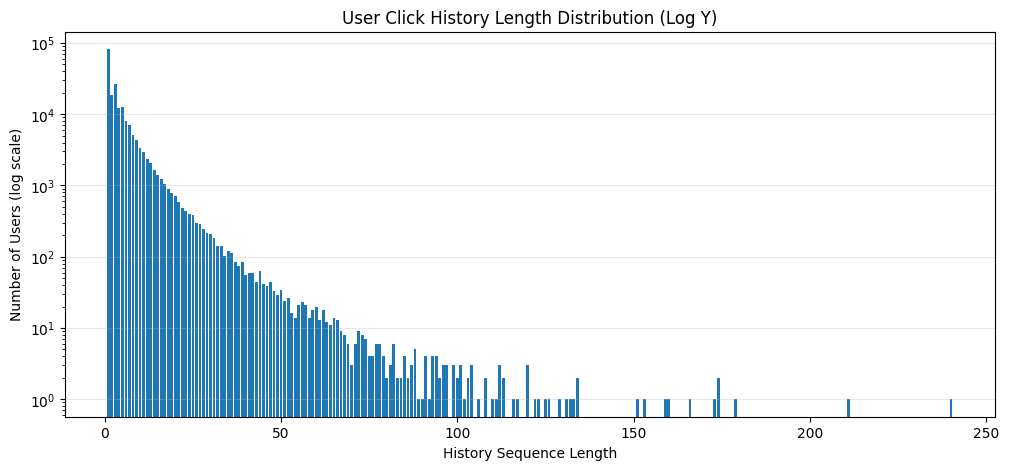

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.bar(len_dist.index, len_dist.values, width=0.8)
plt.yscale("log")
plt.xlabel("History Sequence Length")
plt.ylabel("Number of Users (log scale)")
plt.title("User Click History Length Distribution (Log Y)")
plt.grid(axis='y', alpha=0.3)
plt.show()



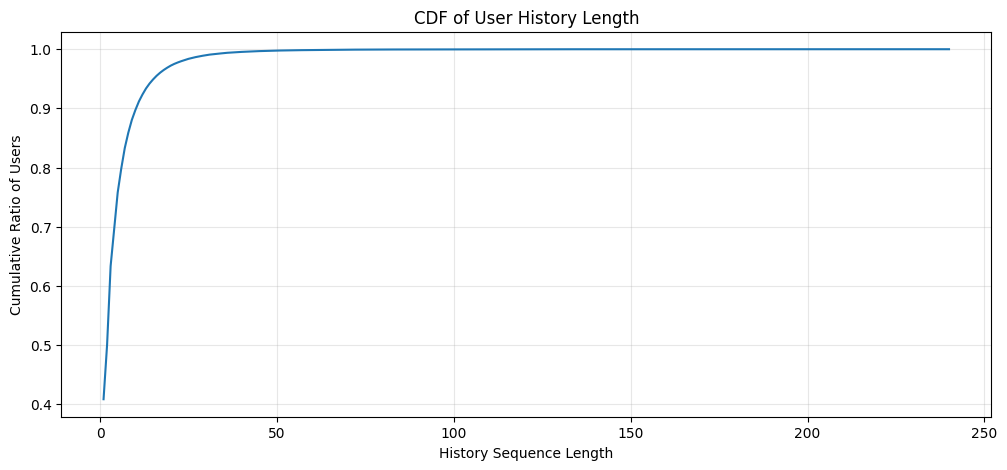

In [11]:
cdf = len_dist.cumsum() / len_dist.sum()

plt.figure(figsize=(12, 5))
plt.plot(cdf.index, cdf.values)
plt.xlabel("History Sequence Length")
plt.ylabel("Cumulative Ratio of Users")
plt.title("CDF of User History Length")
plt.grid(alpha=0.3)
plt.show()


In [12]:
print(all_data.head(3).T)

                                0              1             2
user_id                  0.000000       1.000000      2.000000
click_article_id     30760.000000  289197.000000  36162.000000
click_timestamp          0.330768       0.330669      0.330703
click_environment        4.000000       4.000000      4.000000
click_deviceGroup        1.000000       1.000000      3.000000
click_os                17.000000      17.000000     20.000000
click_country            1.000000       1.000000      1.000000
click_region            25.000000      25.000000     25.000000
click_referrer_type      2.000000       6.000000      2.000000


1.  **[离线模式] 使用训练集：(1112623, 9)**
    - 代表训练集有 1,112,623 条点击记录（行），每条有 9 个字段（如 `user_id`、`click_article_id`、时间等）。
    - 这里的每一行是“用户点击某篇文章”的一次行为。

2.  **用户行为序列数：200000**
    - 代表有 200,000 个不同的用户（`user_id`）。
    - 这是对训练集按 `user_id` 分组后，统计有多少个独立用户。

In [13]:
display(all_data.head())
print(all_data.shape)
print(all_data.columns.tolist())
print(all_data.dtypes)
display(his_behavior_df.head())
print(his_behavior_df.shape)

print(type(his_behavior_df.iloc[0]['hist_click_article_id']))
print(his_behavior_df.iloc[0]['hist_click_article_id'])
print(len(his_behavior_df.iloc[0]['hist_click_article_id']))

uid = his_behavior_df.iloc[0]['user_id']
print("user_id =", uid)

print("\n这个用户在原始点击日志里的记录：")
display(all_data[all_data['user_id'] == uid])

print("\n这个用户聚合后的点击序列：")
print(his_behavior_df[his_behavior_df['user_id'] == uid]['hist_click_article_id'].iloc[0])



,user_id,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
0,0,30760,0.330768,4,1,17,1,25,2
1,1,289197,0.330669,4,1,17,1,25,6
2,2,36162,0.330703,4,3,20,1,25,2
3,3,50644,0.330681,4,3,2,1,25,2
4,4,42567,0.330755,4,1,12,1,16,1


(912623, 9)
['user_id', 'click_article_id', 'click_timestamp', 'click_environment', 'click_deviceGroup', 'click_os', 'click_country', 'click_region', 'click_referrer_type']
user_id                  int64
click_article_id         int64
click_timestamp        float64
click_environment        int64
click_deviceGroup        int64
click_os                 int64
click_country            int64
click_region             int64
click_referrer_type      int64
dtype: object


,user_id,hist_click_article_id,seq_len
0,0,[30760],1
1,1,[289197],1
2,2,[36162],1
3,3,[50644],1
4,4,[42567],1


(200000, 3)
<class 'list'>
[30760]
1
user_id = 0

这个用户在原始点击日志里的记录：


,user_id,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
0,0,30760,0.330768,4,1,17,1,25,2



这个用户聚合后的点击序列：
[30760]


In [14]:
# 合并行为序列到特征表
trn_df = trn_user_item_feats_df.merge(his_behavior_df, on='user_id')

if offline:
    val_df = val_user_item_feats_df.merge(his_behavior_df, on='user_id')
else:
    val_df = None

# 测试集：只在非空时合并
if len(tst_user_item_feats_df) > 0:
    tst_df = tst_user_item_feats_df.merge(his_behavior_df, on='user_id')
else:
    tst_df = tst_user_item_feats_df  # 保持为空 DataFrame

print(f"✅ 合并后训练集: {trn_df.shape}")
if val_df is not None:
    print(f"   合并后验证集: {val_df.shape}")
if len(tst_df) > 0:
    print(f"   合并后测试集: {tst_df.shape}")
else:
    print(f"   合并后测试集: 空（离线模式正常）")

✅ 合并后训练集: (1426880, 33)
   合并后验证集: (8000000, 33)
   合并后测试集: 空（离线模式正常）


In [15]:
print("训练集用户数:", trn_df['user_id'].nunique())
print("训练集样本数:", len(trn_df))
print("训练集平均每用户样本数:", len(trn_df) / trn_df['user_id'].nunique())
print("训练集正样本率:", trn_df['label'].mean())

if offline and val_df is not None:
    print("验证集用户数:", val_df['user_id'].nunique())
    print("验证集样本数:", len(val_df))
    print("验证集平均每用户样本数:", len(val_df) / val_df['user_id'].nunique())
    print("验证集正样本率:", val_df['label'].mean())


训练集用户数: 109760
训练集样本数: 1426880
训练集平均每用户样本数: 13.0
训练集正样本率: 0.07692307692307693
验证集用户数: 40000
验证集样本数: 8000000
验证集平均每用户样本数: 200.0
验证集正样本率: 0.00342275


In [16]:
if offline and val_df is not None:
    val_hit_mask = val_df.groupby('user_id')['label'].transform('max') == 1
    val_df_hit = val_df[val_hit_mask].copy()
    print("验证集 hit 用户数:", val_df_hit['user_id'].nunique())
    print("验证集 hit 用户占比:", val_df_hit['user_id'].nunique() / val_df['user_id'].nunique())
else:
    val_hit_mask = None
    val_df_hit = None


验证集 hit 用户数: 27382
验证集 hit 用户占比: 0.68455


## 2. 特征处理

将特征分为三类，每类在 JRC 模型中的处理方式不同：

| 特征类型 | 示例 | 模型处理 |
|----------|------|----------|
| **稀疏特征** | `user_id`, `click_article_id`, `category_id` | → Embedding → 拼接 |
| **稠密特征** | `sim0`, `time_diff0`, `click_size` | → MinMaxScaler 归一化 → 直接拼接 |
| **行为序列** | `hist_click_article_id` | → Embedding → DIN Attention → 加权池化 |

In [17]:
# 定义特征分组
sparse_fea = [
    'user_id', 'click_article_id', 'category_id',
    'click_environment', 'click_deviceGroup', 'click_os',
    'click_country', 'click_region', 'click_referrer_type',
]

dense_fea = [
    'sim0', 'time_diff0', 'word_diff0',
    'sim_max', 'sim_min', 'sim_sum', 'sim_mean',
    'score', 'rank', 'click_size', 'time_diff_mean',
    'active_level', 'user_time_hob1', 'user_time_hob2',
    'words_hbo', 'words_count','is_cat_hab', 'article_hot_level',
    'article_user_num', 'article_time_diff_mean'
]

hist_behavior_fea = ['hist_click_article_id']

print(f"稀疏特征 ({len(sparse_fea)}): {sparse_fea}")
print(f"稠密特征 ({len(dense_fea)}): {dense_fea}")
print(f"行为序列 ({len(hist_behavior_fea)}): {hist_behavior_fea}")

稀疏特征 (9): ['user_id', 'click_article_id', 'category_id', 'click_environment', 'click_deviceGroup', 'click_os', 'click_country', 'click_region', 'click_referrer_type']
稠密特征 (20): ['sim0', 'time_diff0', 'word_diff0', 'sim_max', 'sim_min', 'sim_sum', 'sim_mean', 'score', 'rank', 'click_size', 'time_diff_mean', 'active_level', 'user_time_hob1', 'user_time_hob2', 'words_hbo', 'words_count', 'is_cat_hab', 'article_hot_level', 'article_user_num', 'article_time_diff_mean']
行为序列 (1): ['hist_click_article_id']


In [18]:
# Dense 特征归一化
print("📊 对 Dense 特征进行 MinMaxScaler 归一化...")
mm = MinMaxScaler()

for feat in dense_fea:
    trn_df[feat] = mm.fit_transform(trn_df[[feat]])
    if offline and val_df is not None:
        val_df[feat] = mm.transform(val_df[[feat]])
    # 保护：只有测试集非空时才归一化
    if len(tst_df) > 0:
        tst_df[feat] = mm.transform(tst_df[[feat]])
    else:
        print(f"   ⚠️ 测试集为空，跳过 {feat} 归一化")

print("✅ Dense 特征归一化完成！")
if len(tst_df) == 0:
    print("⚠️  警告：测试集为空，请检查 4.recall.ipynb 和 5.feature_engineering.ipynb 是否正确运行")

📊 对 Dense 特征进行 MinMaxScaler 归一化...
   ⚠️ 测试集为空，跳过 sim0 归一化
   ⚠️ 测试集为空，跳过 time_diff0 归一化
   ⚠️ 测试集为空，跳过 word_diff0 归一化
   ⚠️ 测试集为空，跳过 sim_max 归一化
   ⚠️ 测试集为空，跳过 sim_min 归一化
   ⚠️ 测试集为空，跳过 sim_sum 归一化
   ⚠️ 测试集为空，跳过 sim_mean 归一化
   ⚠️ 测试集为空，跳过 score 归一化
   ⚠️ 测试集为空，跳过 rank 归一化
   ⚠️ 测试集为空，跳过 click_size 归一化
   ⚠️ 测试集为空，跳过 time_diff_mean 归一化
   ⚠️ 测试集为空，跳过 active_level 归一化
   ⚠️ 测试集为空，跳过 user_time_hob1 归一化
   ⚠️ 测试集为空，跳过 user_time_hob2 归一化
   ⚠️ 测试集为空，跳过 words_hbo 归一化
   ⚠️ 测试集为空，跳过 words_count 归一化
   ⚠️ 测试集为空，跳过 is_cat_hab 归一化
   ⚠️ 测试集为空，跳过 article_hot_level 归一化
   ⚠️ 测试集为空，跳过 article_user_num 归一化
   ⚠️ 测试集为空，跳过 article_time_diff_mean 归一化
✅ Dense 特征归一化完成！
⚠️  警告：测试集为空，请检查 4.recall.ipynb 和 5.feature_engineering.ipynb 是否正确运行


## 3. 构建 PyTorch 输入与模型


In [19]:
emb_dim = 8
max_len = 50

# 只包含非空的 DataFrame
all_frames = [trn_df] + ([val_df] if val_df is not None else []) + ([tst_df] if len(tst_df) > 0 else [])

# ====== 稀疏特征 ID 映射 ======
sparse_maps = {}
for feat in sparse_fea:
    vals = pd.concat([f[feat].astype('int64') for f in all_frames], ignore_index=True)
    # click_article_id 还要包含历史序列中的 ID
    if feat == 'click_article_id':
        hist_vals = []
        for f in all_frames:
            for seq in f['hist_click_article_id']:
                if isinstance(seq, (list, np.ndarray)):
                    hist_vals.extend([int(x) for x in seq])
        if len(hist_vals) > 0:
            vals = pd.concat([vals, pd.Series(hist_vals, dtype='int64')], ignore_index=True)
    _, uniques = pd.factorize(vals, sort=False)
    mapping = {int(val): int(idx) for idx, val in enumerate(uniques)}
    if feat == 'click_article_id':
        mapping = {k: v + 1 for k, v in mapping.items()}  # 保留 0 用于 padding
    sparse_maps[feat] = mapping


def _vocab_size(mapping: dict) -> int:
    return (max(mapping.values()) + 1) if mapping else 1


sparse_vocab_sizes = {feat: _vocab_size(sparse_maps[feat]) for feat in sparse_fea}
click_vocab_size = _vocab_size(sparse_maps['click_article_id'])
dense_input_dim = len(dense_fea)

print("✅ 稀疏特征 ID 映射构建完成")
for feat in sparse_fea:
    print(f"   {feat}: vocab_size = {sparse_vocab_sizes[feat]}")
print(f"   hist_click_article_id 共享 click_article_id vocab_size = {click_vocab_size}")


✅ 稀疏特征 ID 映射构建完成
   user_id: vocab_size = 149760
   click_article_id: vocab_size = 22783
   category_id: vocab_size = 248
   click_environment: vocab_size = 3
   click_deviceGroup: vocab_size = 4
   click_os: vocab_size = 8
   click_country: vocab_size = 11
   click_region: vocab_size = 28
   click_referrer_type: vocab_size = 7
   hist_click_article_id 共享 click_article_id vocab_size = 22783


In [20]:
for feat in sparse_fea:
    print(f"{feat} 前10个映射: {list(sparse_maps[feat].items())[:10]}")


user_id 前10个映射: [(3, 0), (24, 1), (45, 2), (66, 3), (89, 4), (111, 5), (112, 6), (117, 7), (118, 8), (128, 9)]
click_article_id 前10个映射: [(36162, 1), (156279, 2), (205824, 3), (224730, 4), (98003, 5), (96210, 6), (235230, 7), (289003, 8), (338340, 9), (156619, 10)]
category_id 前10个映射: [(43, 0), (281, 1), (331, 2), (354, 3), (216, 4), (209, 5), (375, 6), (418, 7), (437, 8), (186, 9)]
click_environment 前10个映射: [(4, 0), (2, 1), (1, 2)]
click_deviceGroup 前10个映射: [(3, 0), (1, 1), (4, 2), (5, 3)]
click_os 前10个映射: [(2, 0), (17, 1), (20, 2), (12, 3), (19, 4), (13, 5), (5, 6), (3, 7)]
click_country 前10个映射: [(1, 0), (10, 1), (2, 2), (5, 3), (11, 4), (4, 5), (8, 6), (6, 7), (9, 8), (7, 9)]
click_region 前10个映射: [(25, 0), (21, 1), (11, 2), (17, 3), (13, 4), (7, 5), (5, 6), (28, 7), (27, 8), (4, 9)]
click_referrer_type 前10个映射: [(2, 0), (7, 1), (1, 2), (6, 3), (5, 4), (4, 5), (3, 6)]


vocab_size 就是"这个特征有多少种不同的值"，模型要为每种值学习一个 Embedding 向量！

In [21]:
# ====== PyTorch JRC 配置 ======
jrc_config = {
    'shared_dnn_units': [256, 128],
    'logit_head_units': [64],
    'gate_hidden_units': [32],
    'attention_hidden_units': [64, 32],
    'linear_logits': True,
    'dropout_rate': 0.1,
}

print("🏗️ PyTorch JRC 配置准备完成")
print(f"   稀疏特征数: {len(sparse_fea)}")
print(f"   稠密特征数: {dense_input_dim}")
print(f"   Embedding dim: {emb_dim}")
print(f"   Max history len: {max_len}")


🏗️ PyTorch JRC 配置准备完成
   稀疏特征数: 9
   稠密特征数: 20
   Embedding dim: 8
   Max history len: 50


group=['dnn']：这些特征会被送入 DNN（深度神经网络）模型进行学习和建模。

In [22]:
# ====== 构建模型输入字典 ======
def pad_sequences_np(sequences, maxlen, value=0):
    padded = np.full((len(sequences), maxlen), value, dtype=np.int64)
    for idx, seq in enumerate(sequences):
        if len(seq) == 0:
            continue
        trunc = seq[:maxlen]
        padded[idx, :len(trunc)] = np.asarray(trunc, dtype=np.int64)
    return padded


def build_model_input(df: pd.DataFrame) -> dict:
    """将 DataFrame 转换为模型输入字典"""
    model_input = {}
    # 稀疏特征：映射为连续 ID
    for feat in sparse_fea:
        model_input[feat] = (
            df[feat].astype('int64').map(sparse_maps[feat]).fillna(0).astype('int64').values
        )
    # 稠密特征：直接使用归一化后的值
    for feat in dense_fea:
        model_input[feat] = df[feat].astype('float32').values
    # 变长稀疏特征：映射 + pad
    cmap = sparse_maps['click_article_id']
    raw_seq_list = df['hist_click_article_id'].tolist()
    mapped_seq = []
    for seq in raw_seq_list:
        if isinstance(seq, (list, np.ndarray)):
            mapped_seq.append([int(cmap.get(int(x), 0)) if int(x) != 0 else 0 for x in seq])
        else:
            mapped_seq.append([0])
    model_input['hist_click_article_id'] = pad_sequences_np(mapped_seq, max_len, value=0)
    return model_input


print("🔄 构建模型输入...")
x_trn = build_model_input(trn_df)
y_trn = trn_df['label'].values.astype('float32')

if offline and val_df is not None:
    x_val = build_model_input(val_df)
    y_val = val_df['label'].values.astype('float32')

# 测试集：只在非空时构建输入
if len(tst_df) > 0:
    x_tst = build_model_input(tst_df)
else:
    x_tst = None

print(f"   训练集样本数: {len(y_trn)}, 正样本率: {y_trn.mean():.4f}")
if offline:
    print(f"   验证集样本数: {len(y_val)}, 正样本率: {y_val.mean():.4f}")
if x_tst is not None:
    print(f"   测试集样本数: {len(tst_df)}")
else:
    print(f"   测试集: 空（离线模式跳过）")
print("✅ 模型输入构建完成！")


🔄 构建模型输入...
   训练集样本数: 1426880, 正样本率: 0.0769
   验证集样本数: 8000000, 正样本率: 0.0034
   测试集: 空（离线模式跳过）
✅ 模型输入构建完成！


## 4. 构建 PyTorch JRC 模型


In [23]:
ensure_torch_available()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def make_mlp(input_dim, hidden_units, dropout_rate=0.0, output_dim=None, output_activation=None):
    layers = []
    prev_dim = input_dim
    for units in hidden_units:
        layers.append(nn.Linear(prev_dim, units))
        layers.append(nn.ReLU())
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        prev_dim = units
    if output_dim is not None:
        layers.append(nn.Linear(prev_dim, output_dim))
        if output_activation == 'sigmoid':
            layers.append(nn.Sigmoid())
    return nn.Sequential(*layers), (output_dim if output_dim is not None else prev_dim)


class DINAttentionPooling(nn.Module):
    def __init__(self, emb_dim, hidden_units):
        super().__init__()
        self.att_mlp, _ = make_mlp(
            emb_dim * 4,
            hidden_units,
            dropout_rate=0.0,
            output_dim=1,
            output_activation=None,
        )

    def forward(self, query_emb, hist_emb, mask):
        query = query_emb.unsqueeze(1).expand_as(hist_emb)
        att_input = torch.cat([query, hist_emb, query - hist_emb, query * hist_emb], dim=-1)
        scores = self.att_mlp(att_input).squeeze(-1)

        all_pad = ~mask.any(dim=1)
        scores = scores.masked_fill(~mask, -1e9)
        scores = scores.masked_fill(all_pad.unsqueeze(1), 0.0)

        weights = torch.softmax(scores, dim=1)
        weights = weights * mask.float()
        denom = weights.sum(dim=1, keepdim=True).clamp_min(1e-8)
        weights = weights / denom

        pooled = torch.bmm(weights.unsqueeze(1), hist_emb).squeeze(1)
        pooled = pooled.masked_fill(all_pad.unsqueeze(1), 0.0)
        return pooled


class PyTorchJRC(nn.Module):
    def __init__(self, sparse_vocab_sizes, dense_input_dim, emb_dim, max_len, config):
        super().__init__()
        self.sparse_fea = list(sparse_vocab_sizes.keys())
        self.dense_fea = dense_fea
        self.emb_dim = emb_dim
        self.max_len = max_len
        self.use_linear = config.get('linear_logits', True)

        self.sparse_embeddings = nn.ModuleDict()
        for feat, vocab_size in sparse_vocab_sizes.items():
            if feat == 'click_article_id':
                self.sparse_embeddings[feat] = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
            else:
                self.sparse_embeddings[feat] = nn.Embedding(vocab_size, emb_dim)

        if self.use_linear:
            self.linear_sparse_embeddings = nn.ModuleDict({
                feat: nn.Embedding(vocab_size, 1, padding_idx=0 if feat == 'click_article_id' else None)
                for feat, vocab_size in sparse_vocab_sizes.items()
            })
            self.linear_dense = nn.Linear(dense_input_dim, 1)

        self.din_pooling = DINAttentionPooling(emb_dim, config.get('attention_hidden_units', [64, 32]))

        shared_input_dim = len(self.sparse_fea) * emb_dim + dense_input_dim + emb_dim
        self.shared_backbone, shared_output_dim = make_mlp(
            shared_input_dim,
            config.get('shared_dnn_units', [256, 128]),
            dropout_rate=config.get('dropout_rate', 0.0),
            output_dim=None,
        )

        self.logit_head, logit_hidden_dim = make_mlp(
            shared_output_dim,
            config.get('logit_head_units', [64]),
            dropout_rate=config.get('dropout_rate', 0.0),
            output_dim=None,
        )
        self.logits_out = nn.Linear(logit_hidden_dim, 2)

        self.gate_head, gate_hidden_dim = make_mlp(
            shared_output_dim,
            config.get('gate_hidden_units', [32]),
            dropout_rate=config.get('dropout_rate', 0.0),
            output_dim=None,
        )
        self.gate_out = nn.Sequential(nn.Linear(gate_hidden_dim, 1), nn.Sigmoid())

    def forward(self, batch):
        sparse_emb_list = [self.sparse_embeddings[feat](batch[feat]) for feat in self.sparse_fea]
        dense_tensor = torch.stack([batch[feat] for feat in dense_fea], dim=1)

        target_emb = self.sparse_embeddings['click_article_id'](batch['click_article_id'])
        hist_ids = batch['hist_click_article_id']
        hist_emb = self.sparse_embeddings['click_article_id'](hist_ids)
        hist_mask = hist_ids.ne(0)
        hist_repr = self.din_pooling(target_emb, hist_emb, hist_mask)

        dnn_input = torch.cat(sparse_emb_list + [dense_tensor, hist_repr], dim=1)
        shared_repr = self.shared_backbone(dnn_input)

        logits_hidden = self.logit_head(shared_repr)
        logits_2d = self.logits_out(logits_hidden)

        if self.use_linear:
            linear_sparse = sum(
                self.linear_sparse_embeddings[feat](batch[feat]).squeeze(-1)
                for feat in self.sparse_fea
            )
            linear_dense = self.linear_dense(dense_tensor).squeeze(-1)
            linear_logit = linear_sparse + linear_dense
            linear_2d = torch.stack([-linear_logit, linear_logit], dim=1)
            logits_2d = logits_2d + linear_2d

        gate_hidden = self.gate_head(shared_repr)
        gate_lambda = self.gate_out(gate_hidden).squeeze(-1)
        return logits_2d, gate_lambda



def count_parameters(model):
    return sum(param.numel() for param in model.parameters() if param.requires_grad)


def init_jrc_model():
    model = PyTorchJRC(sparse_vocab_sizes, dense_input_dim, emb_dim, max_len, jrc_config).to(DEVICE)
    return model


print("🏗️ 构建 PyTorch JRC 模型...")
model = init_jrc_model()
print(model)
print(f"📦 设备: {DEVICE}")
print(f"📊 可训练参数量: {count_parameters(model):,}")


🏗️ 构建 PyTorch JRC 模型...
PyTorchJRC(
  (sparse_embeddings): ModuleDict(
    (user_id): Embedding(149760, 8)
    (click_article_id): Embedding(22783, 8, padding_idx=0)
    (category_id): Embedding(248, 8)
    (click_environment): Embedding(3, 8)
    (click_deviceGroup): Embedding(4, 8)
    (click_os): Embedding(8, 8)
    (click_country): Embedding(11, 8)
    (click_region): Embedding(28, 8)
    (click_referrer_type): Embedding(7, 8)
  )
  (linear_sparse_embeddings): ModuleDict(
    (user_id): Embedding(149760, 1)
    (click_article_id): Embedding(22783, 1, padding_idx=0)
    (category_id): Embedding(248, 1)
    (click_environment): Embedding(3, 1)
    (click_deviceGroup): Embedding(4, 1)
    (click_os): Embedding(8, 1)
    (click_country): Embedding(11, 1)
    (click_region): Embedding(28, 1)
    (click_referrer_type): Embedding(7, 1)
  )
  (linear_dense): Linear(in_features=20, out_features=1, bias=True)
  (din_pooling): DINAttentionPooling(
    (att_mlp): Sequential(
      (0): Linear(

## 5. 联合损失函数详解

JRC 的核心是基于 **2D logit** 的联合损失函数：

$$L_{total} = \lambda \cdot L_{ranking} + (1 - \lambda) \cdot L_{calibration}$$

其中：
- 模型输出 2D logit $\mathbf{z} = [z_0, z_1]$，排序分数 $s = z_1 - z_0$
- $L_{ranking}$：**Pairwise BPR Loss**，在 batch 内对排序分数 $s$ 做正负样本配对：
  $$L_{rank} = -\frac{1}{|P||N|}\sum_{i \in P}\sum_{j \in N} \log \sigma(s_i - s_j)$$
- $L_{calibration}$：**2-class Cross-Entropy**（on 2D logits, from_logits=True）：
  $$L_{calib} = -\frac{1}{n}\sum_i \log \text{softmax}(\mathbf{z}_i)[y_i]$$
  等价于 $-\frac{1}{n}\sum_i [y_i \log \sigma(s_i) + (1-y_i)\log(1-\sigma(s_i))]$
- $\lambda$：由 **Context Gate** 产生，对每个样本不同，取 batch 均值后加权


### Context Gate 的直觉

- 对于 **"容易区分"** 的样本（正负很分明），$\lambda \to 0$ 偏向校准 → 学精确概率
- 对于 **"难区分"** 的样本（排序边界附近），$\lambda \to 1$ 偏向排序 → 把顺序排对

## JRC 联合损失函数原理与公式详解

### 1. 排序损失（Pairwise BPR Loss）

- **目标**：让正样本的排序分数高于负样本。
- **数学公式**：
  $$
  L_{\text{BPR}} = -\frac{1}{|P||N|} \sum_{i \in P} \sum_{j \in N} \log \sigma(s_i - s_j)
  $$
  其中 $s_i$ 是正样本分数，$s_j$ 是负样本分数，$\sigma$ 是 sigmoid。
- **实现要点**：
  - 对 batch 内所有正负样本两两配对，计算分数差。
  - 用 sigmoid 拉开正负分数差距，log 取均值。

### 2. ListNet 排序损失（可选）

- **目标**：让预测分布和真实分布尽量一致。
- **数学公式**：
  $$
  L_{\text{ListNet}} = -\sum_{i} P(y_i) \log P(\hat{y}_i)
  $$
  其中 $P(y_i)$ 是标签 softmax，$P(\hat{y}_i)$ 是预测分数 softmax。

### 3. 联合排序+校准损失（JRC 核心）

- **2D logit 输出**：$\mathbf{z} = [z_0, z_1]$
  - 排序分数 $s = z_1 - z_0$
  - 校准概率 $p = \text{softmax}(\mathbf{z})[1] = \sigma(z_1 - z_0)$
- **损失函数**：
  $$
  L_{\text{total}} = \lambda \cdot L_{\text{BPR}} + (1-\lambda) \cdot L_{\text{calib}}
  $$
  其中 $\lambda$ 由 Context Gate 动态产生。
- **校准损失**：
  $$
  L_{\text{calib}} = -\frac{1}{N} \sum_{i} \log \text{softmax}(\mathbf{z}_i)[y_i]
  $$
  即 2-class cross-entropy（from_logits=True 自动 softmax）。




In [24]:
ensure_torch_available()


class RankingDictDataset(Dataset):
    def __init__(self, x_dict, y=None):
        self.x_dict = x_dict
        self.y = y
        self.length = len(next(iter(x_dict.values())))

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        sample = {key: value[idx] for key, value in self.x_dict.items()}
        if self.y is None:
            return sample
        return sample, self.y[idx]


class UserGroupedBatchSampler:
    def __init__(self, user_ids, batch_size=256, shuffle=True):
        self.user_ids = np.asarray(user_ids)
        self.batch_size = batch_size
        self.shuffle = shuffle

        user_to_indices = defaultdict(list)
        for idx, uid in enumerate(self.user_ids):
            user_to_indices[int(uid)].append(idx)
        self.user_blocks = list(user_to_indices.values())

    def __iter__(self):
        blocks = list(self.user_blocks)
        if self.shuffle:
            random.shuffle(blocks)

        batch = []
        for block in blocks:
            if len(block) >= self.batch_size:
                if batch:
                    yield batch
                    batch = []
                yield block
                continue

            if len(batch) + len(block) > self.batch_size:
                if batch:
                    yield batch
                batch = list(block)
            else:
                batch.extend(block)

        if batch:
            yield batch

    def __len__(self):
        count = 0
        batch = []
        for block in self.user_blocks:
            if len(block) >= self.batch_size:
                if batch:
                    count += 1
                    batch = []
                count += 1
                continue

            if len(batch) + len(block) > self.batch_size:
                count += 1
                batch = list(block)
            else:
                batch.extend(block)

        if batch:
            count += 1
        return count



def collate_with_labels(batch):
    features, labels = zip(*batch)
    collated = {}
    for key in features[0]:
        arr = np.stack([item[key] for item in features])
        dtype = torch.long if key in sparse_fea or key == 'hist_click_article_id' else torch.float32
        collated[key] = torch.tensor(arr, dtype=dtype)
    return collated, torch.tensor(np.asarray(labels), dtype=torch.float32)



def collate_features(batch):
    collated = {}
    for key in batch[0]:
        arr = np.stack([item[key] for item in batch])
        dtype = torch.long if key in sparse_fea or key == 'hist_click_article_id' else torch.float32
        collated[key] = torch.tensor(arr, dtype=dtype)
    return collated



def make_loader(x_dict, y=None, batch_size=256, shuffle=False, group_by_user=False):
    dataset = RankingDictDataset(x_dict, y)
    if y is None:
        return DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_features)

    if group_by_user:
        batch_sampler = UserGroupedBatchSampler(
            x_dict['user_id'],
            batch_size=batch_size,
            shuffle=shuffle,
        )
        return DataLoader(dataset, batch_sampler=batch_sampler, collate_fn=collate_with_labels)

    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_with_labels)



def move_batch_to_device(batch):
    return {key: value.to(DEVICE) for key, value in batch.items()}



def pairwise_bpr_loss(y_true, y_pred, user_ids):
    user_losses = []

    for uid in torch.unique(user_ids):
        mask = user_ids == uid
        user_labels = y_true[mask]
        user_scores = y_pred[mask]

        pos_scores = user_scores[user_labels == 1]
        neg_scores = user_scores[user_labels == 0]

        if pos_scores.numel() == 0 or neg_scores.numel() == 0:
            continue

        diff = pos_scores.unsqueeze(1) - neg_scores.unsqueeze(0)
        user_loss = -F.logsigmoid(diff).mean()
        user_losses.append(user_loss)

    if not user_losses:
        return y_pred.new_tensor(0.0)

    return torch.stack(user_losses).mean()



def compute_joint_loss(logits_2d, gate_lambdas, y_true, user_ids):
    calib_loss = F.cross_entropy(logits_2d, y_true.long())
    ranking_scores = logits_2d[:, 1] - logits_2d[:, 0]
    rank_loss = pairwise_bpr_loss(y_true, ranking_scores, user_ids)
    avg_lambda = gate_lambdas.mean()
    total_loss = avg_lambda * rank_loss + (1.0 - avg_lambda) * calib_loss
    return total_loss, rank_loss, calib_loss, avg_lambda



def raw_predict_jrc(model, x_data, batch_size=256):
    loader = make_loader(x_data, y=None, batch_size=batch_size, shuffle=False)
    model.eval()
    logits_list = []
    gate_list = []
    with torch.no_grad():
        for batch in loader:
            batch = move_batch_to_device(batch)
            logits_2d, gate_lambdas = model(batch)
            logits_list.append(logits_2d.cpu().numpy())
            gate_list.append(gate_lambdas.cpu().numpy())
    logits_2d = np.concatenate(logits_list, axis=0)
    gate_lambdas = np.concatenate(gate_list, axis=0)
    return logits_2d, gate_lambdas



def softmax_second_col(logits_2d):
    shifted = logits_2d - logits_2d.max(axis=1, keepdims=True)
    exp_logits = np.exp(shifted)
    probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)
    return probs[:, 1]



def build_jrc_predictions(logits_2d, gate_lambdas, mode='fusion'):
    ranking_scores = logits_2d[:, 1] - logits_2d[:, 0]
    calib_probs = softmax_second_col(logits_2d)

    if mode == 'calibration':
        return calib_probs

    r_min, r_max = ranking_scores.min(), ranking_scores.max()
    if r_max > r_min:
        norm_rank = (ranking_scores - r_min) / (r_max - r_min)
    else:
        norm_rank = ranking_scores

    if mode == 'ranking':
        return norm_rank
    if mode == 'fusion':
        return gate_lambdas * norm_rank + (1 - gate_lambdas) * calib_probs
    raise ValueError(f"Unknown mode: {mode}")



def compute_mrr_hr_stats(df, topk=5, score_col='pred_score'):
    df_sorted = df.sort_values(by=['user_id', score_col], ascending=[True, False])
    mrr_sum = hr_sum = user_count = pos_user_count = 0

    for _, group in df_sorted.groupby('user_id'):
        user_count += 1
        labels = group['label'].values
        if labels.sum() == 0:
            continue
        pos_user_count += 1
        pos_idx = np.where(labels == 1)[0]
        if len(pos_idx) > 0:
            rank = pos_idx[0] + 1
            if rank <= topk:
                mrr_sum += 1.0 / rank
                hr_sum += 1

    mrr = mrr_sum / user_count if user_count > 0 else 0.0
    hr = hr_sum / user_count if user_count > 0 else 0.0
    return {
        'mrr5': float(mrr),
        'hr5': float(hr),
        'pos_user_count': int(pos_user_count),
        'user_count': int(user_count),
    }



def compute_ndcg_at_k(labels, preds, user_id_list, k=5):
    group_score = defaultdict(list)
    group_truth = defaultdict(list)
    for idx, uid in enumerate(user_id_list):
        group_score[uid].append(preds[idx])
        group_truth[uid].append(labels[idx])

    ndcg_list = []
    for uid in group_score:
        y_true = np.array([group_truth[uid]])
        y_score = np.array([group_score[uid]])
        if np.sum(y_true) == 0:
            ndcg_list.append(0.0)
        else:
            ndcg_list.append(ndcg_score(y_true, y_score, k=k))
    return float(np.mean(ndcg_list))



def safe_auc(labels, preds):
    labels = np.asarray(labels)
    if np.unique(labels).size < 2:
        return float('nan')
    return float(roc_auc_score(labels, preds))



def evaluate_prediction_slice(labels, preds, eval_df, topk=5):
    eval_frame = eval_df[['user_id', 'click_article_id', 'label']].copy()
    eval_frame['pred_score'] = preds
    rank_metrics = compute_mrr_hr_stats(eval_frame, topk=topk, score_col='pred_score')
    return {
        'auc': safe_auc(labels, preds),
        'ndcg5': compute_ndcg_at_k(labels, preds, eval_df['user_id'].values, k=topk),
        'mrr5': rank_metrics['mrr5'],
        'hr5': rank_metrics['hr5'],
        'pos_user_count': rank_metrics['pos_user_count'],
        'user_count': rank_metrics['user_count'],
    }



def summarize_validation_from_raw(
    logits_2d,
    gate_lambdas,
    y_true,
    val_df,
    val_df_hit=None,
    val_hit_mask=None,
    topk=5,
    mode='fusion',
):
    preds = build_jrc_predictions(logits_2d, gate_lambdas, mode=mode)
    metrics = {'preds': preds}

    full_metrics = evaluate_prediction_slice(y_true, preds, val_df, topk=topk)
    for key, value in full_metrics.items():
        metrics[f'full_{key}'] = value

    if val_df_hit is not None and len(val_df_hit) > 0 and val_hit_mask is not None:
        hit_mask_np = val_hit_mask.to_numpy() if hasattr(val_hit_mask, 'to_numpy') else np.asarray(val_hit_mask)
        hit_preds = preds[hit_mask_np]
        hit_labels = val_df_hit['label'].values
        hit_metrics = evaluate_prediction_slice(hit_labels, hit_preds, val_df_hit, topk=topk)
        metrics['hit_preds'] = hit_preds
        for key, value in hit_metrics.items():
            metrics[f'hit_{key}'] = value
    else:
        for key in ['auc', 'ndcg5', 'mrr5', 'hr5']:
            metrics[f'hit_{key}'] = float('nan')
        metrics['hit_pos_user_count'] = 0
        metrics['hit_user_count'] = 0

    return metrics



def evaluate_jrc_validation(
    model,
    x_val,
    y_val,
    val_df,
    val_df_hit=None,
    val_hit_mask=None,
    batch_size=256,
    topk=5,
    mode='fusion',
):
    logits_2d, gate_lambdas = raw_predict_jrc(model, x_val, batch_size=batch_size)
    metrics = summarize_validation_from_raw(
        logits_2d,
        gate_lambdas,
        y_val,
        val_df,
        val_df_hit=val_df_hit,
        val_hit_mask=val_hit_mask,
        topk=topk,
        mode=mode,
    )
    metrics['logits_2d'] = logits_2d
    metrics['gate_lambdas'] = gate_lambdas
    return metrics



def train_jrc_model(
    model, x_train, y_train, x_val=None, y_val=None,
    val_df=None, val_df_hit=None, val_hit_mask=None,
    epochs=5, batch_size=256, lr=0.001, select_topk=5,
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_loader = make_loader(
        x_train, y_train,
        batch_size=batch_size,
        shuffle=True,
        group_by_user=True,
    )

    history = {
        'total_loss': [],
        'rank_loss': [],
        'calib_loss': [],
        'gate_lambda': [],
        'full_auc': [],
        'full_ndcg5': [],
        'full_mrr5': [],
        'full_hr5': [],
        'hit_auc': [],
        'hit_ndcg5': [],
        'hit_mrr5': [],
        'hit_hr5': [],
    }
    best_metric = float('-inf')
    best_epoch = None
    best_state_dict = None
    best_eval_metrics = None

    for epoch in range(epochs):
        epoch_metrics = {k: [] for k in ['total_loss', 'rank_loss', 'calib_loss', 'gate_lambda']}
        t0 = time.time()
        model.train()

        for x_batch, y_batch in train_loader:
            x_batch = move_batch_to_device(x_batch)
            y_batch = y_batch.to(DEVICE)
            user_ids = x_batch['user_id']

            optimizer.zero_grad()
            logits_2d, gate_lambdas = model(x_batch)
            total_loss, r_loss, c_loss, avg_lam = compute_joint_loss(
                logits_2d, gate_lambdas, y_batch, user_ids
            )
            total_loss.backward()
            optimizer.step()

            epoch_metrics['total_loss'].append(total_loss.item())
            epoch_metrics['rank_loss'].append(r_loss.item())
            epoch_metrics['calib_loss'].append(c_loss.item())
            epoch_metrics['gate_lambda'].append(avg_lam.item())

        elapsed = time.time() - t0
        for key in epoch_metrics:
            history[key].append(float(np.mean(epoch_metrics[key])))

        msg = (
            f"Epoch {epoch + 1}/{epochs} ({elapsed:.1f}s)  "
            f"Total: {history['total_loss'][-1]:.4f}  "
            f"Rank: {history['rank_loss'][-1]:.4f}  "
            f"Calib: {history['calib_loss'][-1]:.4f}  "
            f"Gate λ: {history['gate_lambda'][-1]:.4f}"
        )

        if x_val is not None and y_val is not None and val_df is not None:
            eval_metrics = evaluate_jrc_validation(
                model,
                x_val,
                y_val,
                val_df,
                val_df_hit=val_df_hit,
                val_hit_mask=val_hit_mask,
                batch_size=batch_size,
                topk=select_topk,
                mode='fusion',
            )

            for metric_name in [
                'full_auc', 'full_ndcg5', 'full_mrr5', 'full_hr5',
                'hit_auc', 'hit_ndcg5', 'hit_mrr5', 'hit_hr5',
            ]:
                history[metric_name].append(float(eval_metrics[metric_name]))

            current_metric = eval_metrics['hit_mrr5']
            if np.isnan(current_metric):
                current_metric = eval_metrics['full_mrr5']

            if current_metric > best_metric:
                best_metric = float(current_metric)
                best_epoch = epoch + 1
                best_state_dict = copy.deepcopy(model.state_dict())
                best_eval_metrics = {
                    key: value for key, value in eval_metrics.items()
                    if key not in {'preds', 'hit_preds', 'logits_2d', 'gate_lambdas'}
                }

            msg += (
                f"  | Full MRR@{select_topk}: {eval_metrics['full_mrr5']:.5f}"
                f"  | Hit MRR@{select_topk}: {eval_metrics['hit_mrr5']:.5f}"
                f"  | Full NDCG@{select_topk}: {eval_metrics['full_ndcg5']:.4f}"
                f"  | Hit NDCG@{select_topk}: {eval_metrics['hit_ndcg5']:.4f}"
            )
            if best_epoch == epoch + 1:
                msg += "  | best*"

        print(msg)

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    history['best_epoch'] = best_epoch
    history['best_metric'] = None if best_metric == float('-inf') else float(best_metric)
    history['best_eval_metrics'] = best_eval_metrics

    return model, history


print("✅ 训练函数定义完成")


✅ 训练函数定义完成


## 6. 训练 JRC 模型

In [25]:
# ====== user-wise batch / loss 健康检查（可选） ======
print("🧪 检查 user-grouped batch 和 user-wise loss...")

tmp_loader = make_loader(
    x_trn, y_trn,
    batch_size=256,
    shuffle=True,
    group_by_user=True,
)

tmp_x, tmp_y = next(iter(tmp_loader))
uids = tmp_x['user_id'].numpy()

print("batch 样本数:", len(uids))
print("batch 用户数:", len(np.unique(uids)))
print(pd.Series(uids).value_counts().head(10))
print("label 分布:")
print(pd.Series(tmp_y.numpy()).value_counts())

tmp_x_device = move_batch_to_device(tmp_x)
tmp_y_device = tmp_y.to(DEVICE)
tmp_user_ids = tmp_x_device['user_id']

model.eval()
with torch.no_grad():
    tmp_logits_2d, tmp_gate_lambdas = model(tmp_x_device)
    tmp_total_loss, tmp_r_loss, tmp_c_loss, tmp_avg_lam = compute_joint_loss(
        tmp_logits_2d, tmp_gate_lambdas, tmp_y_device, tmp_user_ids
    )

print("total_loss:", float(tmp_total_loss.item()))
print("rank_loss:", float(tmp_r_loss.item()))
print("calib_loss:", float(tmp_c_loss.item()))
print("avg_lambda:", float(tmp_avg_lam.item()))


🧪 检查 user-grouped batch 和 user-wise loss...
batch 样本数: 247
batch 用户数: 19
95035    13
12170    13
71740    13
75954    13
59061    13
77622    13
31479    13
79176    13
63567    13
89119    13
Name: count, dtype: int64
label 分布:
0.0    228
1.0     19
Name: count, dtype: int64
total_loss: 1.8648204803466797
rank_loss: 2.500640630722046
calib_loss: 1.28220534324646
avg_lambda: 0.4781665802001953


In [26]:
print("🏋️ 开始训练 JRC 模型...")
print("训练集(hit-only, sampled)用户数:", trn_df['user_id'].nunique())
print("训练集(hit-only, sampled)样本数:", len(trn_df))
print("训练集(hit-only, sampled)平均每用户样本数:", len(trn_df) / trn_df['user_id'].nunique())

if offline and val_df is not None:
    print("验证集(全量候选)用户数:", val_df['user_id'].nunique())
    print("验证集(全量候选)样本数:", len(val_df))

print(f"   训练集样本数: {len(y_trn)}")
if offline:
    print(f"   验证集样本数: {len(y_val)}")
print()

model, train_history = train_jrc_model(
    model, x_trn, y_trn,
    x_val=x_val if offline else None,
    y_val=y_val if offline else None,
    val_df=val_df if offline else None,
    val_df_hit=val_df_hit if offline else None,
    val_hit_mask=val_hit_mask if offline else None,
    epochs=5,
    batch_size=256,
    lr=0.001,
    select_topk=5,
)

if offline and train_history.get('best_epoch') is not None:
    best_metrics = train_history.get('best_eval_metrics', {}) or {}
    print()
    print(f"🎯 Best checkpoint epoch: {train_history['best_epoch']}")
    print(f"   best hit-only MRR@5: {train_history['best_metric']:.5f}")
    print(f"   对应 full MRR@5: {best_metrics.get('full_mrr5', float('nan')):.5f}")
    print(f"   对应 hit NDCG@5: {best_metrics.get('hit_ndcg5', float('nan')):.4f}")
    print(f"   对应 hit HR@5: {best_metrics.get('hit_hr5', float('nan')):.5f}")

print()
print("✅ JRC 模型训练完成！")


🏋️ 开始训练 JRC 模型...
训练集(hit-only, sampled)用户数: 109760
训练集(hit-only, sampled)样本数: 1426880
训练集(hit-only, sampled)平均每用户样本数: 13.0
验证集(全量候选)用户数: 40000
验证集(全量候选)样本数: 8000000
   训练集样本数: 1426880
   验证集样本数: 8000000

Epoch 1/5 (96.4s)  Total: 0.3550  Rank: 0.5316  Calib: 0.3543  Gate λ: 0.0011  | Full MRR@5: 0.14722  | Hit MRR@5: 0.21507  | Full NDCG@5: 0.1774  | Hit NDCG@5: 0.2592  | best*
Epoch 2/5 (97.5s)  Total: 0.3016  Rank: 0.3606  Calib: 0.3016  Gate λ: 0.0000  | Full MRR@5: 0.17440  | Hit MRR@5: 0.25477  | Full NDCG@5: 0.2072  | Hit NDCG@5: 0.3026  | best*
Epoch 3/5 (98.0s)  Total: 0.2829  Rank: 0.3170  Calib: 0.2829  Gate λ: 0.0000  | Full MRR@5: 0.17640  | Hit MRR@5: 0.25768  | Full NDCG@5: 0.2090  | Hit NDCG@5: 0.3052  | best*
Epoch 4/5 (110.1s)  Total: 0.2682  Rank: 0.2829  Calib: 0.2682  Gate λ: 0.0000  | Full MRR@5: 0.18281  | Hit MRR@5: 0.26705  | Full NDCG@5: 0.2165  | Hit NDCG@5: 0.3163  | best*
Epoch 5/5 (98.8s)  Total: 0.2556  Rank: 0.2561  Calib: 0.2556  Gate λ: 0.0000  | Full 

### JRC 模型训练日志指标说明
JRC（Joint Ranking & Calibration）模型核心是联合优化排序和校准任务，通过门控网络动态调整两者的损失权重。训练日志中各核心指标含义如下：

1. **Total（总损失）**
   总损失 $L$ 由排序损失和校准损失加权求和得到，计算公式为：
   $$L = \lambda \cdot L_{rank} + (1-\lambda) \cdot L_{calib}$$
   其中 $\lambda$ 为门控权重（Gate λ），用于动态调整两种损失的占比。

2. **Rank（排序损失）**
   即 $L_{rank}$，用于优化推荐排序效果（常用 BPR、Pairwise loss 等），核心目标是提升模型区分「点击样本」与「未点击样本」的能力。

3. **Calib（校准损失）**
   即 $L_{calib}$，通常采用交叉熵损失，用于优化模型输出概率的准确性，使预测概率尽可能接近真实点击概率。

4. **Gate λ（门控权重）**
   由独立的 DNN 网络输出（激活函数为 sigmoid），取值范围为 $[0,1]$，由模型自动学习。该权重决定当前 batch/样本中排序损失和校准损失的权重分配比例。

5. **Val AUC（验证集 AUC）**
   指验证集上的曲线下面积（Area Under Curve），是衡量模型排序能力的核心指标。AUC 值越高，代表模型区分正负样本的能力越强。



## 7. 预测与评估

JRC 模型输出 2D logit $\mathbf{z} = [z_0, z_1]$，从中可以衍生不同的预测分数：

| 模式 | 公式 | 适用场景 |
|------|------|----------|
| `calibration` | $p = \sigma(z_1 - z_0)$ | 需要准确 CTR 概率估计 |
| `ranking` | $s = z_1 - z_0$ (归一化) | 只关心排序质量 |
| `fusion` | $\lambda \cdot s_{norm} + (1-\lambda) \cdot p$ | 综合最优（推荐使用） |

In [27]:
def predict_jrc(model, x_data, batch_size=256, mode='fusion'):
    """
    JRC 模型预测函数（PyTorch 2D Logit 版本）
    """
    logits_2d, gate_lambdas = raw_predict_jrc(model, x_data, batch_size=batch_size)
    return build_jrc_predictions(logits_2d, gate_lambdas, mode=mode)


print("✅ 预测函数定义完成")


✅ 预测函数定义完成


In [28]:
# ====== 评估辅助函数 ======

def norm_sim(sim_df, weight=0.0):
    """分数归一化到 [0, 1]"""
    min_sim = sim_df.min()
    max_sim = sim_df.max()
    if max_sim == min_sim:
        sim_df = sim_df.apply(lambda sim: 1.0)
    else:
        sim_df = sim_df.apply(lambda sim: 1.0 * (sim - min_sim) / (max_sim - min_sim))
    sim_df = sim_df.apply(lambda sim: sim + weight)
    return sim_df



def calculate_mrr_metrics(df, topk=5, score_col='pred_score'):
    """计算 MRR@K 和 HR@K"""
    metrics = compute_mrr_hr_stats(df, topk=topk, score_col=score_col)
    print(f"   MRR@{topk}: {metrics['mrr5']:.5f}")
    print(f"   HR@{topk}:  {metrics['hr5']:.5f}")
    print(f"   有正样本用户: {metrics['pos_user_count']}/{metrics['user_count']}")
    return metrics['mrr5'], metrics['hr5']



def cal_ndcg(labels, preds, user_id_list, k=5):
    """分用户计算 NDCG@k"""
    return compute_ndcg_at_k(labels, preds, user_id_list, k=k)



def submit(recall_df, topk=5, model_name=None):
    """生成提交文件（仅在线模式使用）"""
    recall_df = recall_df.sort_values(by=['user_id', 'pred_score'])
    recall_df['rank'] = recall_df.groupby(['user_id'])['pred_score'].rank(
        ascending=False, method='first'
    )
    tmp = recall_df.groupby('user_id').apply(lambda x: x['rank'].max())
    assert tmp.min() >= topk, f"部分用户候选文章数不足 {topk} 篇！"

    del recall_df['pred_score']
    sub = recall_df[recall_df['rank'] <= topk].set_index(['user_id', 'rank']).unstack(-1).reset_index()
    sub.columns = [int(col) if isinstance(col, int) else col for col in sub.columns.droplevel(0)]
    sub = sub.rename(columns={
        '': 'user_id', 1: 'article_1', 2: 'article_2',
        3: 'article_3', 4: 'article_4', 5: 'article_5',
    })
    save_name = output_path / (model_name + '_' + datetime.today().strftime('%m-%d') + '.csv')
    sub.to_csv(save_name, index=False, header=True)
    print(f"📁 提交文件已保存: {save_name}")


print("✅ 评估辅助函数定义完成")


✅ 评估辅助函数定义完成


In [29]:
# ====== 全面评估 JRC 模型（离线模式）======
if offline:
    print("📈 " + "=" * 60)
    print("📈  JRC 模型 - 验证集效果评估")
    print("📈 " + "=" * 60)

    if train_history.get('best_epoch') is not None:
        best_metrics = train_history.get('best_eval_metrics', {}) or {}
        print()
        print(f"🎯 使用 best checkpoint: epoch {train_history['best_epoch']}")
        print(f"   best hit-only MRR@5: {train_history['best_metric']:.5f}")
        print(f"   对应 full MRR@5: {best_metrics.get('full_mrr5', float('nan')):.5f}")
        print(f"   对应 hit NDCG@5: {best_metrics.get('hit_ndcg5', float('nan')):.4f}")
        print(f"   对应 hit HR@5: {best_metrics.get('hit_hr5', float('nan')):.5f}")

    # 获取两个输出: logits_2d [N,2] + gate_lambda [N,]
    val_logits_2d, val_gate_raw = raw_predict_jrc(model, x_val, batch_size=256)

    # 从 2D logit 衍生排序分数和校准概率
    val_ranking_scores = val_logits_2d[:, 1] - val_logits_2d[:, 0]
    val_calib_probs = softmax_second_col(val_logits_2d)

    print()
    print("🔍 2D Logit 统计:")
    print(f"   z₀ 均值: {val_logits_2d[:, 0].mean():.4f}, z₁ 均值: {val_logits_2d[:, 1].mean():.4f}")
    print(f"   排序分数 s=z₁-z₀ 范围: [{val_ranking_scores.min():.4f}, {val_ranking_scores.max():.4f}]")
    print(f"   校准概率 p=σ(s) 均值: {val_calib_probs.mean():.4f}")

    print()
    print("🔍 门控网络 (Context Gate) 统计:")
    print(f"   λ 均值: {val_gate_raw.mean():.4f}")
    print(f"   λ 标准差: {val_gate_raw.std():.4f}")
    print(f"   λ 范围: [{val_gate_raw.min():.4f}, {val_gate_raw.max():.4f}]")
    print(f"   → λ > 0.5 (偏排序): {(val_gate_raw > 0.5).mean():.2%}")
    print(f"   → λ < 0.5 (偏校准): {(val_gate_raw <= 0.5).mean():.2%}")

    modes = ['calibration', 'ranking', 'fusion']
    mode_labels = ['Calibration (校准概率 σ(z₁-z₀))', 'Ranking (排序分数 z₁-z₀)', 'Fusion (门控融合)']

    print()
    print('=' * 60)
    for mode, label in zip(modes, mode_labels):
        metrics = summarize_validation_from_raw(
            val_logits_2d,
            val_gate_raw,
            y_val,
            val_df,
            val_df_hit=val_df_hit,
            val_hit_mask=val_hit_mask,
            topk=5,
            mode=mode,
        )

        print()
        print(f"📊 【{label}】")
        print(f"   AUC:    {metrics['full_auc']:.4f}")
        print(f"   NDCG@5: {metrics['full_ndcg5']:.4f}")
        print(f"   MRR@5: {metrics['full_mrr5']:.5f}")
        print(f"   HR@5:  {metrics['full_hr5']:.5f}")
        print(f"   有正样本用户: {metrics['full_pos_user_count']}/{metrics['full_user_count']}")

        if val_df_hit is not None and len(val_df_hit) > 0:
            print("   [Hit-only]")
            print(f"   AUC:    {metrics['hit_auc']:.4f}")
            print(f"   NDCG@5: {metrics['hit_ndcg5']:.4f}")
            print(f"   MRR@5: {metrics['hit_mrr5']:.5f}")
            print(f"   HR@5:  {metrics['hit_hr5']:.5f}")
            print(f"   有正样本用户: {metrics['hit_pos_user_count']}/{metrics['hit_user_count']}")

    print()
    print('=' * 60)
    print("✅ 评估完成！")
else:
    print("⏭️ 在线模式跳过验证集评估")


📈 ============================================================
📈  JRC 模型 - 验证集效果评估
📈 ============================================================

🎯 使用 best checkpoint: epoch 5
   best hit-only MRR@5: 0.27117
   对应 full MRR@5: 0.18563
   对应 hit NDCG@5: 0.3202
   对应 hit HR@5: 0.46965

🔍 2D Logit 统计:
   z₀ 均值: 3.4970, z₁ 均值: -3.6409
   排序分数 s=z₁-z₀ 范围: [-40.4881, 9.2447]
   校准概率 p=σ(s) 均值: 0.0391

🔍 门控网络 (Context Gate) 统计:
   λ 均值: 0.0000
   λ 标准差: 0.0000
   λ 范围: [0.0000, 0.0023]
   → λ > 0.5 (偏排序): 0.00%
   → λ < 0.5 (偏校准): 100.00%


📊 【Calibration (校准概率 σ(z₁-z₀))】
   AUC:    0.8788
   NDCG@5: 0.2192
   MRR@5: 0.18563
   HR@5:  0.32150
   有正样本用户: 27382/40000
   [Hit-only]
   AUC:    0.8798
   NDCG@5: 0.3202
   MRR@5: 0.27117
   HR@5:  0.46965
   有正样本用户: 27382/27382

📊 【Ranking (排序分数 z₁-z₀)】
   AUC:    0.8788
   NDCG@5: 0.2192
   MRR@5: 0.18563
   HR@5:  0.32150
   有正样本用户: 27382/40000
   [Hit-only]
   AUC:    0.8798
   NDCG@5: 0.3202
   MRR@5: 0.27117
   HR@5:  0.46965
   有正样本用户: 27382/



#### 1. 2D Logit 统计
| 指标 | 含义 |
|------|------|
| z₀ 均值 / z₁ 均值 | 模型输出的两类 logit（未点击/点击）平均值|
| 排序分数 s=z₁-z₀ 范围 | 排序分数的最小值/最大值，衡量模型区分「点击」与「未点击」样本的能力边界 |
| 校准概率 p=σ(s) 均值 | 通过 softmax 转换得到的点击概率平均值，反映模型输出概率的整体分布特征 |

#### 2. 门控网络 (Context Gate) 统计
| 指标 | 含义 |
|------|------|
| λ 均值 / 标准差 / 范围 | 门控权重 λ 的统计特征，反映验证集上模型对「排序损失」和「校准损失」的权重分配规律 |
| λ > 0.5 (偏排序) | λ 大于 0.5 的样本占比，代表这些样本训练时更侧重优化排序损失 |
| λ < 0.5 (偏校准) | λ 小于等于 0.5 的样本占比，代表这些样本训练时更侧重优化校准损失 |

#### 3. 三种预测方式效果对比
模型支持三种预测策略，每种策略均输出 AUC、NDCG@5、MRR 核心指标，具体说明：

| 预测方式 | 计算逻辑 | 适用场景 | 评估指标含义 |
|----------|----------|----------|--------------|
| Calibration | 基于校准概率（softmax 输出）预测 | 概率预估类任务（如点击率预测） |  AUC：排序能力<br>-NDCG@5：前5个推荐结果的排序质量<br> MRR：推荐列表中首个正确结果的位置 |
| Ranking | 基于排序分数（z₁-z₀）预测 | 纯排序类任务（如推荐列表排序） | 同上 |
| Fusion | 门控融合（结合排序分数+校准概率） | 需要兼顾排序效果和概率准确性的场景 | 同上 |

## 8. 五折交叉验证 + 生成 OOF 特征

使用五折交叉验证生成 out-of-fold 预测，用于后续 Stacking 融合。

In [30]:
print("🔄 开始 JRC 模型五折交叉验证...")


def get_kfold_users(df, n=5):
    user_ids = df['user_id'].unique()
    return [user_ids[i::n] for i in range(n)]


k_fold = 5
user_set = get_kfold_users(trn_df, n=k_fold)

score_list = []
score_df = trn_df[['user_id', 'click_article_id', 'label']].copy()

# 初始化累加数组（根据模式和测试集是否为空决定）
if not offline and len(tst_df) > 0:
    sub_preds = np.zeros(len(tst_df))
elif offline:
    val_sub_preds = np.zeros(len(val_df))

for n_fold, valid_user in enumerate(user_set):
    print()
    print(f"   📁 Fold {n_fold + 1}/{k_fold}")
    fold_trn = trn_df[~trn_df['user_id'].isin(valid_user)]
    fold_val = trn_df[trn_df['user_id'].isin(valid_user)]
    fold_val_hit_mask = fold_val.groupby('user_id')['label'].transform('max') == 1
    fold_val_hit = fold_val[fold_val_hit_mask].copy()

    x_fold_trn = build_model_input(fold_trn)
    y_fold_trn = fold_trn['label'].values.astype('float32')
    x_fold_val = build_model_input(fold_val)
    y_fold_val = fold_val['label'].values.astype('float32')

    fold_model = init_jrc_model()
    fold_model, fold_history = train_jrc_model(
        fold_model, x_fold_trn, y_fold_trn,
        x_val=x_fold_val, y_val=y_fold_val,
        val_df=fold_val,
        val_df_hit=fold_val_hit,
        val_hit_mask=fold_val_hit_mask,
        epochs=3, batch_size=256, lr=0.001,
        select_topk=5,
    )
    if fold_history.get('best_epoch') is not None:
        print(
            f"      best_epoch={fold_history['best_epoch']}, "
            f"hit-only MRR@5={fold_history['best_metric']:.5f}"
        )

    fold_val_preds = predict_jrc(fold_model, x_fold_val, mode='fusion')
    fold_val_copy = fold_val[['user_id', 'click_article_id']].copy()
    fold_val_copy['pred_score'] = fold_val_preds
    fold_val_copy['pred_score'] = fold_val_copy['pred_score'].transform(lambda x: norm_sim(x))
    fold_val_copy['pred_rank'] = fold_val_copy.groupby('user_id')['pred_score'].rank(
        ascending=False, method='first'
    )
    score_list.append(fold_val_copy)

    if not offline and x_tst is not None:
        sub_preds += predict_jrc(fold_model, x_tst, mode='fusion')
    elif offline:
        val_sub_preds += predict_jrc(fold_model, x_val, mode='fusion')

    del fold_model
    gc.collect()
    if TORCH_AVAILABLE and torch.cuda.is_available():
        torch.cuda.empty_cache()

score_df_ = pd.concat(score_list, axis=0)
score_df = score_df.merge(score_df_, how='left', on=['user_id', 'click_article_id'])
score_df[['user_id', 'click_article_id', 'pred_score', 'pred_rank', 'label']].to_csv(
    save_path / 'trn_jrc_feats_all.csv', index=False
)
print()
print("   ✅ 训练集 OOF 特征已保存: trn_jrc_feats_all.csv")

if not offline and x_tst is not None:
    tst_df['pred_score'] = sub_preds / k_fold
    tst_df['pred_score'] = tst_df['pred_score'].transform(lambda x: norm_sim(x))
    tst_df['pred_rank'] = tst_df.groupby('user_id')['pred_score'].rank(
        ascending=False, method='first'
    )
    tst_df[['user_id', 'click_article_id', 'pred_score', 'pred_rank']].to_csv(
        save_path / 'tst_jrc_feats_all.csv', index=False
    )
    print(f"   ✅ 测试集 CV 特征已保存: tst_jrc_feats_all.csv")

    rank_results = tst_df[['user_id', 'click_article_id', 'pred_score']].copy()
    rank_results['click_article_id'] = rank_results['click_article_id'].astype(int)
    submit(rank_results, topk=5, model_name='jrc_cv_all')
elif not offline and x_tst is None:
    print("   ⚠️ 测试集为空，跳过 CV 特征保存和提交文件生成")
    print("   请检查前面的 4.recall_all.ipynb 和 5.feature_engineering_all.ipynb")
else:
    val_df_jrc = val_df[['user_id', 'click_article_id', 'label']].copy()
    val_df_jrc['pred_score'] = val_sub_preds / k_fold
    val_df_jrc['pred_score'] = val_df_jrc['pred_score'].transform(lambda x: norm_sim(x))
    val_df_jrc.to_csv(save_path / 'jrc_val_score_all.csv', index=False)
    print(f"   ✅ 验证集预测已保存: jrc_val_score_all.csv")

    print()
    print("📊 【JRC 五折 CV - 验证集详细指标】")
    cv_auc = roc_auc_score(val_df_jrc['label'], val_df_jrc['pred_score'])
    cv_ndcg = cal_ndcg(
        val_df_jrc['label'].values, val_df_jrc['pred_score'].values,
        val_df_jrc['user_id'].values, k=5,
    )
    print(f"   AUC:    {cv_auc:.4f}")
    print(f"   NDCG@5: {cv_ndcg:.4f}")
    calculate_mrr_metrics(val_df_jrc, topk=5)

print()
print("✅ JRC 五折交叉验证完成！")


🔄 开始 JRC 模型五折交叉验证...

   📁 Fold 1/5
Epoch 1/3 (72.6s)  Total: 0.3688  Rank: 0.5664  Calib: 0.3679  Gate λ: 0.0016  | Full MRR@5: 0.55958  | Hit MRR@5: 0.55958  | Full NDCG@5: 0.6394  | Hit NDCG@5: 0.6394  | best*
Epoch 2/3 (73.4s)  Total: 0.3079  Rank: 0.3759  Calib: 0.3079  Gate λ: 0.0001  | Full MRR@5: 0.60181  | Hit MRR@5: 0.60181  | Full NDCG@5: 0.6763  | Hit NDCG@5: 0.6763  | best*
Epoch 3/3 (76.4s)  Total: 0.2869  Rank: 0.3231  Calib: 0.2869  Gate λ: 0.0000  | Full MRR@5: 0.61917  | Hit MRR@5: 0.61917  | Full NDCG@5: 0.6938  | Hit NDCG@5: 0.6938  | best*
      best_epoch=3, hit-only MRR@5=0.61917

   📁 Fold 2/5
Epoch 1/3 (70.5s)  Total: 0.3613  Rank: 0.5465  Calib: 0.3602  Gate λ: 0.0013  | Full MRR@5: 0.56677  | Hit MRR@5: 0.56677  | Full NDCG@5: 0.6441  | Hit NDCG@5: 0.6441  | best*
Epoch 2/3 (73.3s)  Total: 0.3017  Rank: 0.3595  Calib: 0.3017  Gate λ: 0.0001  | Full MRR@5: 0.59993  | Hit MRR@5: 0.59993  | Full NDCG@5: 0.6751  | Hit NDCG@5: 0.6751  | best*
Epoch 3/3 (71.6s)  To

## 9. 在线模式 - 生成提交文件（单模型）

如果 `MODE = "online"`，使用全量训练好的 JRC 模型预测测试集并生成提交文件。

In [31]:
if not offline:
    if x_tst is not None and len(tst_df) > 0:
        print("🔮 [在线模式] 使用全量模型预测测试集...")

        for mode in ['calibration', 'ranking', 'fusion']:
            preds = predict_jrc(model, x_tst, mode=mode)
            result_df = tst_df[['user_id', 'click_article_id']].copy()
            result_df['pred_score'] = preds
            result_df['click_article_id'] = result_df['click_article_id'].astype(int)

            result_df.to_csv(output_path / f'jrc_{mode}_score_all.csv', index=False)
            submit(result_df.copy(), topk=5, model_name=f'jrc_{mode}_all')

        print("✅ 所有提交文件生成完成！")
    else:
        print("⚠️ [在线模式] 测试集为空，无法生成提交文件")
        print("   请检查前面的 4.recall_all.ipynb 和 5.feature_engineering_all.ipynb")
else:
    print("⏭️ [离线模式] 跳过提交文件生成")


⏭️ [离线模式] 跳过提交文件生成


## 10. 总结

### 本 Notebook 实现了什么？

我们将 **"Joint Optimization of Ranking and Calibration with Contextualized Hybrid Model"**
论文的核心思想应用于新闻推荐排序任务：

1. **Shared Backbone**：基于 DIN 的共享特征提取器，捕捉用户兴趣与候选文章的关联
2. **2D Logit Head**（核心创新）：输出 $\mathbf{z} = [z_0, z_1]$，从同一表示解耦出：
   - 排序分数 $s = z_1 - z_0$（无界 log-odds，梯度不饱和）
   - 校准概率 $p = \sigma(s)$（proper scoring rule，保证校准）
3. **Context Gate**：动态学习每个样本的排序/校准权重 $\lambda$
4. **Joint Loss**：$L = \lambda \cdot L_{rank}(s) + (1 - \lambda) \cdot L_{calib}(\mathbf{z})$

### 2D Logit 的核心优势

| 传统 1D | JRC 2D |
|---------|--------|
| $p = \sigma(z)$，排序和校准用同一个标量 | $\mathbf{z} = [z_0, z_1]$，排序 $s = z_1 - z_0$，校准 $p = \sigma(s)$ |
| sigmoid 饱和导致排序梯度消失 | $s$ 无界，梯度不饱和 |
| BCE 同时承担排序 + 校准 | BPR on $s$ + CE on $\mathbf{z}$，各自保持最优性质 |

### 与原始 `6.ranking.ipynb` 的对比

| 维度 | 原始方案 | JRC 方案 |
|------|---------|----------|
| 模型数量 | LGBMRanker + LGBMClassifier + DIN = 3 个 | JRC = **1 个** |
| 输出设计 | 各模型独立 1D 输出 | 2D Logit 统一表示 |
| 融合方式 | 手动权重 0.3/0.4/0.3 | Context Gate **自动学习** |
| 上下文自适应 | ❌ 静态权重 | ✅ 每样本动态 $\lambda$ |

### 关键超参数调优建议

| 超参数 | 当前值 | 调优方向 |
|--------|--------|----------|
| `shared_dnn_units` | [256, 128] | 增大可提升表达力（如 [512, 256]），但可能过拟合 |
| `logit_head_units` | [64] | 2D Logit Head 隐层，可尝试 [128] 或 [64, 32] |
| `epochs` | 5 | 监控 Val AUC 选择最佳 epoch |
| `batch_size` | 256 | 增大 batch 有利于 BPR Loss（更多正负对） |
| `lr` | 0.001 | 尝试 warmup + cosine decay |
| `dropout_rate` | 0.1 | 防过拟合，0.1~0.3 |
| `emb_dim` | 8 | 可以尝试 16 或 32 |

## 11. ge_loss 实验区（统一 10 Epoch 公平对比）

这一部分用于在**不影响主线 `base_jrc`** 的前提下，统一对比两条 ge_loss 实验线：

- `paper_ge_loss_old`
- `balanced_ge_loss`

统一规则：
- 训练轮数都固定为 `10 epoch`
- 两条实验线都同时维护两套读分方式：
  - `score_mode='diff'` -> `z1-z0`
  - `score_mode='click'` -> `z1`
- 最终统一输出一张公平对比表

说明：
- 主线 `base_jrc` 不重训，只作为 `epochs=5` 的 baseline 展示
- 当前仍然只使用 `hit-only` 训练特征


In [32]:
# ====== ge_loss 实验统一函数定义（10 Epoch 公平对比） ======
print("🧪 准备 ge_loss 统一实验框架...")


def build_experiment_pred_score(logits_2d, score_mode='diff'):
    if score_mode == 'diff':
        return logits_2d[:, 1] - logits_2d[:, 0]
    if score_mode == 'click':
        return logits_2d[:, 1]
    raise ValueError(f'Unknown score_mode: {score_mode}')



def evaluate_experiment_from_raw(
    logits_2d,
    y_true,
    val_df,
    val_df_hit=None,
    val_hit_mask=None,
    topk=5,
    score_mode='diff',
):
    preds = build_experiment_pred_score(logits_2d, score_mode=score_mode)
    metrics = {'preds': preds, 'logits_2d': logits_2d}

    full_metrics = evaluate_prediction_slice(y_true, preds, val_df, topk=topk)
    for key, value in full_metrics.items():
        metrics[f'full_{key}'] = value

    if val_df_hit is not None and len(val_df_hit) > 0 and val_hit_mask is not None:
        hit_mask_np = val_hit_mask.to_numpy() if hasattr(val_hit_mask, 'to_numpy') else np.asarray(val_hit_mask)
        hit_preds = preds[hit_mask_np]
        hit_labels = val_df_hit['label'].values
        hit_metrics = evaluate_prediction_slice(hit_labels, hit_preds, val_df_hit, topk=topk)
        metrics['hit_preds'] = hit_preds
        for key, value in hit_metrics.items():
            metrics[f'hit_{key}'] = value
    else:
        for key in ['auc', 'ndcg5', 'mrr5', 'hr5']:
            metrics[f'hit_{key}'] = float('nan')
        metrics['hit_pos_user_count'] = 0
        metrics['hit_user_count'] = 0

    return metrics



def paper_context_ge_loss_old(logits_2d, labels_onehot, context_ids):
    batch_size = logits_2d.size(0)
    if batch_size == 0:
        return logits_2d.new_tensor(0.0)

    mask = context_ids.unsqueeze(0).eq(context_ids.unsqueeze(1))
    mask_f = mask.float()

    logits_tile = logits_2d.unsqueeze(1).expand(-1, batch_size, -1).clone()
    labels_tile = labels_onehot.unsqueeze(1).expand(-1, batch_size, -1).float()

    invalid_mask = ~mask.unsqueeze(-1)
    logits_tile = logits_tile.masked_fill(invalid_mask, -1e9)
    labels_tile = labels_tile * mask.unsqueeze(-1).float()

    l_neg = logits_tile[:, :, 0]
    l_pos = logits_tile[:, :, 1]
    y_neg = labels_tile[:, :, 0]
    y_pos = labels_tile[:, :, 1]

    log_softmax_pos = F.log_softmax(l_pos, dim=0)
    log_softmax_neg = F.log_softmax(l_neg, dim=0)

    loss_pos = -(y_pos * log_softmax_pos).sum(dim=0)
    loss_neg = -(y_neg * log_softmax_neg).sum(dim=0)

    context_sizes = mask_f.sum(dim=0).clamp_min(1.0)
    ge_loss = ((loss_pos + loss_neg) / context_sizes).mean()
    return ge_loss



def paper_context_ge_loss_balanced(
    logits_2d,
    labels_onehot,
    context_ids,
    pos_weight=1.0,
    neg_weight=1.0,
):
    batch_size = logits_2d.size(0)
    if batch_size == 0:
        return logits_2d.new_tensor(0.0)

    mask = context_ids.unsqueeze(0).eq(context_ids.unsqueeze(1))

    logits_tile = logits_2d.unsqueeze(1).expand(-1, batch_size, -1).clone()
    labels_tile = labels_onehot.unsqueeze(1).expand(-1, batch_size, -1).float()

    invalid_mask = ~mask.unsqueeze(-1)
    logits_tile = logits_tile.masked_fill(invalid_mask, -1e9)
    labels_tile = labels_tile * mask.unsqueeze(-1).float()

    l_neg = logits_tile[:, :, 0]
    l_pos = logits_tile[:, :, 1]
    y_neg = labels_tile[:, :, 0]
    y_pos = labels_tile[:, :, 1]

    log_softmax_pos = F.log_softmax(l_pos, dim=0)
    log_softmax_neg = F.log_softmax(l_neg, dim=0)

    loss_pos = -(y_pos * log_softmax_pos).sum(dim=0)
    loss_neg = -(y_neg * log_softmax_neg).sum(dim=0)

    pos_cnt = y_pos.sum(dim=0).clamp_min(1.0)
    neg_cnt = y_neg.sum(dim=0).clamp_min(1.0)

    ge_loss = (
        pos_weight * loss_pos / pos_cnt +
        neg_weight * loss_neg / neg_cnt
    ).mean()
    return ge_loss



def compute_joint_loss_ge_old(logits_2d, y_true, context_ids, alpha=0.5):
    ce_loss = F.cross_entropy(logits_2d, y_true.long())
    y_true_long = y_true.long()
    y_neg = 1 - y_true_long
    labels_onehot = torch.stack([y_neg, y_true_long], dim=1).float()
    ge_loss = paper_context_ge_loss_old(logits_2d, labels_onehot, context_ids)
    total_loss = alpha * ce_loss + (1.0 - alpha) * ge_loss
    return total_loss, ce_loss, ge_loss



def compute_joint_loss_ge_balanced(
    logits_2d,
    y_true,
    context_ids,
    alpha=0.5,
    pos_weight=1.0,
    neg_weight=1.0,
):
    ce_loss = F.cross_entropy(logits_2d, y_true.long())
    y_true_long = y_true.long()
    y_neg = 1 - y_true_long
    labels_onehot = torch.stack([y_neg, y_true_long], dim=1).float()
    ge_loss = paper_context_ge_loss_balanced(
        logits_2d,
        labels_onehot,
        context_ids,
        pos_weight=pos_weight,
        neg_weight=neg_weight,
    )
    total_loss = alpha * ce_loss + (1.0 - alpha) * ge_loss
    return total_loss, ce_loss, ge_loss



def train_experiment_model(
    model,
    x_train,
    y_train,
    x_val=None,
    y_val=None,
    val_df=None,
    val_df_hit=None,
    val_hit_mask=None,
    epochs=10,
    batch_size=256,
    lr=0.001,
    select_topk=5,
    loss_type='old_ge',
    alpha=0.5,
    pos_weight=1.0,
    neg_weight=1.0,
    score_modes=('diff', 'click'),
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_loader = make_loader(
        x_train,
        y_train,
        batch_size=batch_size,
        shuffle=True,
        group_by_user=True,
    )

    history = {
        'total_loss': [],
        'ce_loss': [],
        'ge_loss': [],
    }
    for score_mode in score_modes:
        history[f'{score_mode}_full_mrr5'] = []
        history[f'{score_mode}_hit_mrr5'] = []
        history[f'{score_mode}_full_ndcg5'] = []
        history[f'{score_mode}_hit_ndcg5'] = []

    best_records = {
        score_mode: {
            'metric': float('-inf'),
            'epoch': None,
            'state_dict': None,
            'eval_metrics': None,
        }
        for score_mode in score_modes
    }

    for epoch in range(epochs):
        epoch_metrics = {k: [] for k in ['total_loss', 'ce_loss', 'ge_loss']}
        t0 = time.time()
        model.train()

        for x_batch, y_batch in train_loader:
            x_batch = move_batch_to_device(x_batch)
            y_batch = y_batch.to(DEVICE)
            context_ids = x_batch['user_id']

            optimizer.zero_grad()
            logits_2d, _ = model(x_batch)
            if loss_type == 'old_ge':
                total_loss, ce_loss, ge_loss = compute_joint_loss_ge_old(
                    logits_2d,
                    y_batch,
                    context_ids,
                    alpha=alpha,
                )
            elif loss_type == 'balanced_ge':
                total_loss, ce_loss, ge_loss = compute_joint_loss_ge_balanced(
                    logits_2d,
                    y_batch,
                    context_ids,
                    alpha=alpha,
                    pos_weight=pos_weight,
                    neg_weight=neg_weight,
                )
            else:
                raise ValueError(f'Unknown loss_type: {loss_type}')

            total_loss.backward()
            optimizer.step()

            epoch_metrics['total_loss'].append(total_loss.item())
            epoch_metrics['ce_loss'].append(ce_loss.item())
            epoch_metrics['ge_loss'].append(ge_loss.item())

        elapsed = time.time() - t0
        for key in epoch_metrics:
            history[key].append(float(np.mean(epoch_metrics[key])))

        msg = (
            f"Epoch {epoch + 1}/{epochs} ({elapsed:.1f}s)  "
            f"Total: {history['total_loss'][-1]:.4f}  "
            f"CE: {history['ce_loss'][-1]:.4f}  "
            f"GE: {history['ge_loss'][-1]:.4f}"
        )

        if x_val is not None and y_val is not None and val_df is not None:
            val_logits_2d, _ = raw_predict_jrc(model, x_val, batch_size=batch_size)
            for score_mode in score_modes:
                eval_metrics = evaluate_experiment_from_raw(
                    val_logits_2d,
                    y_val,
                    val_df,
                    val_df_hit=val_df_hit,
                    val_hit_mask=val_hit_mask,
                    topk=select_topk,
                    score_mode=score_mode,
                )

                history[f'{score_mode}_full_mrr5'].append(float(eval_metrics['full_mrr5']))
                history[f'{score_mode}_hit_mrr5'].append(float(eval_metrics['hit_mrr5']))
                history[f'{score_mode}_full_ndcg5'].append(float(eval_metrics['full_ndcg5']))
                history[f'{score_mode}_hit_ndcg5'].append(float(eval_metrics['hit_ndcg5']))

                current_metric = eval_metrics['hit_mrr5']
                if np.isnan(current_metric):
                    current_metric = eval_metrics['full_mrr5']

                if current_metric > best_records[score_mode]['metric']:
                    best_records[score_mode]['metric'] = float(current_metric)
                    best_records[score_mode]['epoch'] = epoch + 1
                    best_records[score_mode]['state_dict'] = copy.deepcopy(model.state_dict())
                    best_records[score_mode]['eval_metrics'] = {
                        key: value for key, value in eval_metrics.items()
                        if key not in {'preds', 'hit_preds', 'logits_2d'}
                    }

            msg += (
                f"  | diff Hit MRR@{select_topk}: {history['diff_hit_mrr5'][-1]:.5f}"
                f"  | click Hit MRR@{select_topk}: {history['click_hit_mrr5'][-1]:.5f}"
                f"  | diff Full MRR@{select_topk}: {history['diff_full_mrr5'][-1]:.5f}"
                f"  | click Full MRR@{select_topk}: {history['click_full_mrr5'][-1]:.5f}"
            )

        print(msg)

    result = {
        'history': history,
        'best_records': {
            mode: {
                'metric': None if rec['metric'] == float('-inf') else float(rec['metric']),
                'epoch': rec['epoch'],
                'state_dict': rec['state_dict'],
                'eval_metrics': rec['eval_metrics'],
            }
            for mode, rec in best_records.items()
        }
    }
    return model, result


print("✅ ge_loss 统一实验函数定义完成")


🧪 准备 ge_loss 统一实验框架...
✅ ge_loss 统一实验函数定义完成


In [33]:
# ====== ge_loss 实验区：batch sanity check ======
print("🧪 检查旧版/平衡版 ge_loss 的 batch sanity check...")

sanity_loader = make_loader(
    x_trn,
    y_trn,
    batch_size=256,
    shuffle=True,
    group_by_user=True,
)

sanity_x, sanity_y = next(iter(sanity_loader))
print("batch 样本数:", len(sanity_y))
print("batch context 数:", sanity_x['user_id'].nunique() if hasattr(sanity_x['user_id'], 'nunique') else len(np.unique(sanity_x['user_id'])))
print(pd.Series(sanity_x['user_id']).value_counts().head(10))

sanity_x_device = move_batch_to_device(sanity_x)
sanity_y_device = sanity_y.to(DEVICE)
sanity_context_ids = sanity_x_device['user_id']

sanity_model = init_jrc_model()
sanity_model.eval()
with torch.no_grad():
    sanity_logits, _ = sanity_model(sanity_x_device)
    old_total, old_ce, old_ge = compute_joint_loss_ge_old(
        sanity_logits,
        sanity_y_device,
        sanity_context_ids,
        alpha=0.5,
    )
    bal_total, bal_ce, bal_ge = compute_joint_loss_ge_balanced(
        sanity_logits,
        sanity_y_device,
        sanity_context_ids,
        alpha=0.5,
        pos_weight=1.0,
        neg_weight=1.0,
    )

print("old_ge -> ce_loss:", float(old_ce.item()), " ge_loss:", float(old_ge.item()), " total_loss:", float(old_total.item()))
print("balanced_ge -> ce_loss:", float(bal_ce.item()), " ge_loss:", float(bal_ge.item()), " total_loss:", float(bal_total.item()))


🧪 检查旧版/平衡版 ge_loss 的 batch sanity check...
batch 样本数: 247
batch context 数: 19
42866     13
91336     13
61242     13
106028    13
71645     13
64951     13
73073     13
75435     13
41639     13
62691     13
Name: count, dtype: int64
old_ge -> ce_loss: 0.8958616852760315  ge_loss: 3.3205878734588623  total_loss: 2.108224868774414
balanced_ge -> ce_loss: 0.8958616852760315  ge_loss: 6.579185485839844  total_loss: 3.7375235557556152


In [34]:
# ====== ge_loss 实验区：统一 10 epoch 公平对比 ======
EXPERIMENT_EPOCHS = 10
print(f"🚀 开始 ge_loss 公平对比实验（epochs={EXPERIMENT_EPOCHS}）...")

# 1) 旧版 ge_loss（双读分）
print("\n" + "=" * 70)
print("🚀 旧版 paper_ge_loss 公平对比（diff + click）")
print("=" * 70)
old_ge_model = init_jrc_model()
old_ge_model, old_ge_result = train_experiment_model(
    old_ge_model,
    x_trn,
    y_trn,
    x_val=x_val if offline else None,
    y_val=y_val if offline else None,
    val_df=val_df if offline else None,
    val_df_hit=val_df_hit if offline else None,
    val_hit_mask=val_hit_mask if offline else None,
    epochs=EXPERIMENT_EPOCHS,
    batch_size=256,
    lr=0.001,
    select_topk=5,
    loss_type='old_ge',
    alpha=0.5,
)

# 2) 平衡版 ge_loss（双读分）
print("\n" + "=" * 70)
print("🚀 平衡版 balanced_ge_loss 公平对比（diff + click）")
print("=" * 70)
balanced_ge_model = init_jrc_model()
balanced_ge_model, balanced_ge_result = train_experiment_model(
    balanced_ge_model,
    x_trn,
    y_trn,
    x_val=x_val if offline else None,
    y_val=y_val if offline else None,
    val_df=val_df if offline else None,
    val_df_hit=val_df_hit if offline else None,
    val_hit_mask=val_hit_mask if offline else None,
    epochs=EXPERIMENT_EPOCHS,
    batch_size=256,
    lr=0.001,
    select_topk=5,
    loss_type='balanced_ge',
    alpha=0.5,
    pos_weight=1.0,
    neg_weight=1.0,
)

rows = []

if 'train_history' in globals() and isinstance(train_history, dict):
    base_metrics = train_history.get('best_eval_metrics', {}) or {}
    rows.append({
        'model': 'base_jrc',
        'score_mode': 'diff',
        'setting': '-',
        'epochs': 5,
        'best_epoch': train_history.get('best_epoch'),
        'best_hit_mrr5': train_history.get('best_metric', float('nan')),
        'best_full_mrr5': base_metrics.get('full_mrr5', float('nan')),
        'best_hit_ndcg5': base_metrics.get('hit_ndcg5', float('nan')),
        'best_full_ndcg5': base_metrics.get('full_ndcg5', float('nan')),
        'best_hit_hr5': base_metrics.get('hit_hr5', float('nan')),
        'best_full_hr5': base_metrics.get('full_hr5', float('nan')),
    })

for score_mode in ['diff', 'click']:
    rec = old_ge_result['best_records'][score_mode]
    metrics = rec.get('eval_metrics', {}) or {}
    rows.append({
        'model': 'paper_ge_loss_old',
        'score_mode': score_mode,
        'setting': 'alpha=0.5',
        'epochs': EXPERIMENT_EPOCHS,
        'best_epoch': rec.get('epoch'),
        'best_hit_mrr5': rec.get('metric', float('nan')),
        'best_full_mrr5': metrics.get('full_mrr5', float('nan')),
        'best_hit_ndcg5': metrics.get('hit_ndcg5', float('nan')),
        'best_full_ndcg5': metrics.get('full_ndcg5', float('nan')),
        'best_hit_hr5': metrics.get('hit_hr5', float('nan')),
        'best_full_hr5': metrics.get('full_hr5', float('nan')),
    })

for score_mode in ['diff', 'click']:
    rec = balanced_ge_result['best_records'][score_mode]
    metrics = rec.get('eval_metrics', {}) or {}
    rows.append({
        'model': 'balanced_ge_loss',
        'score_mode': score_mode,
        'setting': 'alpha=0.5, neg_weight=1.0',
        'epochs': EXPERIMENT_EPOCHS,
        'best_epoch': rec.get('epoch'),
        'best_hit_mrr5': rec.get('metric', float('nan')),
        'best_full_mrr5': metrics.get('full_mrr5', float('nan')),
        'best_hit_ndcg5': metrics.get('hit_ndcg5', float('nan')),
        'best_full_ndcg5': metrics.get('full_ndcg5', float('nan')),
        'best_hit_hr5': metrics.get('hit_hr5', float('nan')),
        'best_full_hr5': metrics.get('full_hr5', float('nan')),
    })

experiment_compare_df = pd.DataFrame(rows).sort_values(
    ['best_hit_mrr5', 'best_full_mrr5'], ascending=False
).reset_index(drop=True)
print("\n📊 ge_loss 公平对比结果表:")
print(experiment_compare_df)


🚀 开始 ge_loss 公平对比实验（epochs=10）...

🚀 旧版 paper_ge_loss 公平对比（diff + click）
Epoch 1/10 (83.7s)  Total: 1.4912  CE: 0.3547  GE: 2.6277  | diff Hit MRR@5: 0.21468  | click Hit MRR@5: 0.23319  | diff Full MRR@5: 0.14696  | click Full MRR@5: 0.15963
Epoch 2/10 (83.2s)  Total: 1.4104  CE: 0.2966  GE: 2.5241  | diff Hit MRR@5: 0.25468  | click Hit MRR@5: 0.26164  | diff Full MRR@5: 0.17434  | click Full MRR@5: 0.17910
Epoch 3/10 (83.5s)  Total: 1.3889  CE: 0.2781  GE: 2.4997  | diff Hit MRR@5: 0.26288  | click Hit MRR@5: 0.26735  | diff Full MRR@5: 0.17996  | click Full MRR@5: 0.18301
Epoch 4/10 (85.3s)  Total: 1.3740  CE: 0.2631  GE: 2.4850  | diff Hit MRR@5: 0.27602  | click Hit MRR@5: 0.27821  | diff Full MRR@5: 0.18895  | click Full MRR@5: 0.19045
Epoch 5/10 (86.2s)  Total: 1.3632  CE: 0.2511  GE: 2.4753  | diff Hit MRR@5: 0.28014  | click Hit MRR@5: 0.28097  | diff Full MRR@5: 0.19177  | click Full MRR@5: 0.19234
Epoch 6/10 (83.9s)  Total: 1.3548  CE: 0.2411  GE: 2.4685  | diff Hit MRR@5: 

## 13. 追加实验：full-user balanced_ge_loss + click(z1)

并行加载 `fulluser_ge` 训练特征，保持主线和 hit-only ge_loss 对比结果不变。
- miss 用户每人保留 10 个负样本（由特征工程生成）
- miss 用户 context loss 权重固定为 `0.3`
- 训练配置固定为当前最优：`balanced_ge_loss + alpha=0.5 + neg_weight=1.0 + score=z1 + 10 epoch`

In [40]:
# ====== full-user balanced_ge_loss: 数据加载与模型输入 ======
FULLUSER_TRAIN_PATH = save_path / 'trn_user_item_feats_df_fulluser_ge.csv'
FULLUSER_VAL_PATH = save_path / 'val_user_item_feats_df_fulluser_ge.csv'
FULLUSER_TST_PATH = save_path / 'tst_user_item_feats_df_fulluser_ge.csv'
FULLUSER_EPOCHS = 10
FULLUSER_MISS_WEIGHT = 0.3

if not FULLUSER_TRAIN_PATH.exists():
    raise FileNotFoundError(
        f'未找到 {FULLUSER_TRAIN_PATH.name}，请先在 5.feature_engineering_all.ipynb 生成 full-user 实验特征。'
    )

print("\n" + "=" * 70)
print("🧪 加载 full-user GE 实验特征")
print("=" * 70)

trn_user_item_feats_df_fulluser_ge = pd.read_csv(FULLUSER_TRAIN_PATH)
trn_user_item_feats_df_fulluser_ge['click_article_id'] = trn_user_item_feats_df_fulluser_ge['click_article_id'].astype(int)
print(f"   full-user 训练特征: {trn_user_item_feats_df_fulluser_ge.shape}")

if offline and FULLUSER_VAL_PATH.exists():
    val_user_item_feats_df_fulluser_ge = pd.read_csv(FULLUSER_VAL_PATH)
    val_user_item_feats_df_fulluser_ge['click_article_id'] = val_user_item_feats_df_fulluser_ge['click_article_id'].astype(int)
else:
    val_user_item_feats_df_fulluser_ge = val_user_item_feats_df.copy() if offline else None

if FULLUSER_TST_PATH.exists():
    tst_user_item_feats_df_fulluser_ge = pd.read_csv(FULLUSER_TST_PATH)
    if len(tst_user_item_feats_df_fulluser_ge) > 0 and 'click_article_id' in tst_user_item_feats_df_fulluser_ge.columns:
        tst_user_item_feats_df_fulluser_ge['click_article_id'] = tst_user_item_feats_df_fulluser_ge['click_article_id'].astype(int)
else:
    tst_user_item_feats_df_fulluser_ge = tst_user_item_feats_df.copy()

trn_df_fulluser_ge = trn_user_item_feats_df_fulluser_ge.merge(his_behavior_df, on='user_id')
if offline and val_user_item_feats_df_fulluser_ge is not None:
    val_df_fulluser_ge = val_user_item_feats_df_fulluser_ge.merge(his_behavior_df, on='user_id')
else:
    val_df_fulluser_ge = None
if len(tst_user_item_feats_df_fulluser_ge) > 0:
    tst_df_fulluser_ge = tst_user_item_feats_df_fulluser_ge.merge(his_behavior_df, on='user_id')
else:
    tst_df_fulluser_ge = tst_user_item_feats_df_fulluser_ge

print("📊 full-user 训练集统计:")
print(f"   用户数: {trn_df_fulluser_ge['user_id'].nunique()}")
print(f"   样本数: {len(trn_df_fulluser_ge)}")
print(f"   正样本率: {trn_df_fulluser_ge['label'].mean():.6f}")
if 'is_hit_context' in trn_df_fulluser_ge.columns:
    user_flag_df = trn_df_fulluser_ge[['user_id', 'is_hit_context']].drop_duplicates('user_id')
    hit_user_num = int((user_flag_df['is_hit_context'] > 0.5).sum())
    miss_user_num = int((user_flag_df['is_hit_context'] <= 0.5).sum())
    print(f"   hit 用户数: {hit_user_num}")
    print(f"   miss 用户数: {miss_user_num}")
    print(f"   miss 用户平均样本数: {trn_df_fulluser_ge[trn_df_fulluser_ge['is_hit_context'] <= 0.5].groupby('user_id').size().mean():.2f}")

print("📊 对 full-user Dense 特征进行 MinMaxScaler 归一化...")
fulluser_mm = MinMaxScaler()
for feat in dense_fea:
    trn_df_fulluser_ge[feat] = fulluser_mm.fit_transform(trn_df_fulluser_ge[[feat]])
    if offline and val_df_fulluser_ge is not None:
        val_df_fulluser_ge[feat] = fulluser_mm.transform(val_df_fulluser_ge[[feat]])
    if len(tst_df_fulluser_ge) > 0:
        tst_df_fulluser_ge[feat] = fulluser_mm.transform(tst_df_fulluser_ge[[feat]])
print("✅ full-user Dense 特征归一化完成！")


def build_sparse_maps_from_frames(frames):
    sparse_maps_local = {}
    for feat in sparse_fea:
        vals = pd.concat([f[feat].astype('int64') for f in frames], ignore_index=True)
        if feat == 'click_article_id':
            hist_vals = []
            for f in frames:
                for seq in f['hist_click_article_id']:
                    if isinstance(seq, (list, np.ndarray)):
                        hist_vals.extend([int(x) for x in seq])
            if len(hist_vals) > 0:
                vals = pd.concat([vals, pd.Series(hist_vals, dtype='int64')], ignore_index=True)
        _, uniques = pd.factorize(vals, sort=False)
        mapping = {int(val): int(idx) for idx, val in enumerate(uniques)}
        if feat == 'click_article_id':
            mapping = {k: v + 1 for k, v in mapping.items()}
        sparse_maps_local[feat] = mapping
    return sparse_maps_local


def build_model_input_local(df, sparse_maps_local, extra_float_feats=None):
    model_input = {}
    for feat in sparse_fea:
        model_input[feat] = (
            df[feat].astype('int64').map(sparse_maps_local[feat]).fillna(0).astype('int64').values
        )
    for feat in dense_fea:
        model_input[feat] = df[feat].astype('float32').values
    extra_float_feats = extra_float_feats or []
    for feat in extra_float_feats:
        if feat in df.columns:
            model_input[feat] = df[feat].astype('float32').values
    cmap = sparse_maps_local['click_article_id']
    raw_seq_list = df['hist_click_article_id'].tolist()
    mapped_seq = []
    for seq in raw_seq_list:
        if isinstance(seq, (list, np.ndarray)):
            mapped_seq.append([int(cmap.get(int(x), 0)) if int(x) != 0 else 0 for x in seq])
        else:
            mapped_seq.append([0])
    model_input['hist_click_article_id'] = pad_sequences_np(mapped_seq, max_len, value=0)
    return model_input


def init_jrc_model_local(sparse_vocab_sizes_local):
    return PyTorchJRC(sparse_vocab_sizes_local, dense_input_dim, emb_dim, max_len, jrc_config).to(DEVICE)


fulluser_frames = [trn_df_fulluser_ge] + ([val_df_fulluser_ge] if val_df_fulluser_ge is not None else []) + ([tst_df_fulluser_ge] if len(tst_df_fulluser_ge) > 0 else [])
sparse_maps_fulluser_ge = build_sparse_maps_from_frames(fulluser_frames)
sparse_vocab_sizes_fulluser_ge = {feat: (max(mapping.values()) + 1 if mapping else 1) for feat, mapping in sparse_maps_fulluser_ge.items()}

x_trn_fulluser_ge = build_model_input_local(
    trn_df_fulluser_ge,
    sparse_maps_fulluser_ge,
    extra_float_feats=['is_hit_context'],
)
y_trn_fulluser_ge = trn_df_fulluser_ge['label'].values.astype('float32')

if offline and val_df_fulluser_ge is not None:
    x_val_fulluser_ge = build_model_input_local(val_df_fulluser_ge, sparse_maps_fulluser_ge)
    y_val_fulluser_ge = val_df_fulluser_ge['label'].values.astype('float32')
else:
    x_val_fulluser_ge = None
    y_val_fulluser_ge = None

print("✅ full-user 模型输入构建完成")
print(f"   训练样本数: {len(y_trn_fulluser_ge)}")
if y_val_fulluser_ge is not None:
    print(f"   验证样本数: {len(y_val_fulluser_ge)}")



🧪 加载 full-user GE 实验特征
   full-user 训练特征: (1929280, 32)
📊 full-user 训练集统计:
   用户数: 160000
   样本数: 1929280
   正样本率: 0.056892
   hit 用户数: 109760
   miss 用户数: 50240
   miss 用户平均样本数: 10.00
📊 对 full-user Dense 特征进行 MinMaxScaler 归一化...
✅ full-user Dense 特征归一化完成！
✅ full-user 模型输入构建完成
   训练样本数: 1929280
   验证样本数: 8000000


In [41]:
# ====== full-user balanced_ge_loss: first-batch sanity check ======
print("\n" + "=" * 70)
print("🩺 full-user first-batch sanity check")
print("=" * 70)

preview_loader = make_loader(
    x_trn_fulluser_ge,
    y_trn_fulluser_ge,
    batch_size=256,
    shuffle=True,
    group_by_user=True,
)
preview_x, preview_y = next(iter(preview_loader))
preview_uids = preview_x['user_id'].numpy()
preview_hit_flags = preview_x.get('is_hit_context')

print(f"batch 样本数: {len(preview_y)}")
print(f"batch context 数: {len(np.unique(preview_uids))}")
print("每个 context 样本数(前10个):")
print(pd.Series(preview_uids).value_counts().head(10))
if preview_hit_flags is not None:
    hit_ctx = int((preview_hit_flags.numpy() > 0.5).sum())
    miss_ctx = int((preview_hit_flags.numpy() <= 0.5).sum())
    print(f"batch hit context 标记样本数: {hit_ctx}")
    print(f"batch miss context 标记样本数: {miss_ctx}")
print(f"batch label 均值: {float(preview_y.numpy().mean()):.6f}")

preview_x = move_batch_to_device(preview_x)
preview_y = preview_y.to(DEVICE)
preview_context_ids = preview_x['user_id']
preview_hit_flags = preview_x.get('is_hit_context')

preview_model = init_jrc_model_local(sparse_vocab_sizes_fulluser_ge)
preview_model.eval()

with torch.no_grad():
    preview_logits_2d, _ = preview_model(preview_x)

    total_terms = []
    ce_terms = []
    ge_terms = []
    weight_terms = []

    for uid in torch.unique(preview_context_ids):
        mask = preview_context_ids == uid
        logits_ctx = preview_logits_2d[mask]
        y_ctx = preview_y[mask]
        local_context_ids = torch.zeros_like(y_ctx, dtype=preview_context_ids.dtype)

        ce_ctx = F.cross_entropy(logits_ctx, y_ctx.long())
        y_ctx_long = y_ctx.long()
        y_ctx_neg = 1 - y_ctx_long
        labels_onehot_ctx = torch.stack([y_ctx_neg, y_ctx_long], dim=1).float()
        ge_ctx = paper_context_ge_loss_balanced(
            logits_ctx,
            labels_onehot_ctx,
            local_context_ids,
            pos_weight=1.0,
            neg_weight=1.0,
        )
        total_ctx = 0.5 * ce_ctx + 0.5 * ge_ctx

        if preview_hit_flags is not None:
            ctx_weight = 1.0 if float(preview_hit_flags[mask][0].item()) > 0.5 else FULLUSER_MISS_WEIGHT
        else:
            ctx_weight = 1.0

        total_terms.append(total_ctx * ctx_weight)
        ce_terms.append(ce_ctx * ctx_weight)
        ge_terms.append(ge_ctx * ctx_weight)
        weight_terms.append(ctx_weight)

    denom = preview_logits_2d.new_tensor(sum(weight_terms)).clamp_min(1e-8)
    preview_total = torch.stack(total_terms).sum() / denom
    preview_ce = torch.stack(ce_terms).sum() / denom
    preview_ge = torch.stack(ge_terms).sum() / denom

print(f"total_loss: {float(preview_total.item()):.6f}")
print(f"ce_loss: {float(preview_ce.item()):.6f}")
print(f"ge_loss: {float(preview_ge.item()):.6f}")
print(f"max_abs_logit: {float(preview_logits_2d.abs().max().item()):.6f}")
print("logits 前5行:")
print(preview_logits_2d[:5].detach().cpu().numpy())

print("\n判断建议:")
print("- 如果这里的 CE/GE 一开始就是几千、几万甚至更大，优先怀疑 full-user 实现路径仍有 bug。")
print("- 如果这里是正常量级（例如 CE 在 0.x~几，GE 在几以内或十以内），但训练若干轮后才爆，更像优化/目标冲突问题。")



🩺 full-user first-batch sanity check
batch 样本数: 245
batch context 数: 20
每个 context 样本数(前10个):
44424     13
140182    13
85494     13
41174     13
147814    13
15966     13
27371     13
56656     13
75948     13
80164     13
Name: count, dtype: int64
batch hit context 标记样本数: 195
batch miss context 标记样本数: 50
batch label 均值: 0.061224
total_loss: 3.950980
ce_loss: 1.754397
ge_loss: 6.147563
max_abs_logit: 6.332707
logits 前5行:
[[ 3.0403674  -3.0577424 ]
 [-0.09332818  0.07140761]
 [ 2.3836396  -2.451115  ]
 [-0.41510454  0.37370056]
 [ 3.8331232  -3.8927324 ]]

判断建议:
- 如果这里的 CE/GE 一开始就是几千、几万甚至更大，优先怀疑 full-user 实现路径仍有 bug。
- 如果这里是正常量级（例如 CE 在 0.x~几，GE 在几以内或十以内），但训练若干轮后才爆，更像优化/目标冲突问题。


In [42]:
# ====== full-user balanced_ge_loss: 训练与对比 ======
print("\n" + "=" * 70)
print("🚀 full-user balanced_ge_loss + click(z1) 实验")
print("=" * 70)


def compute_joint_loss_ge_balanced_fulluser(
    logits_2d,
    y_true,
    context_ids,
    is_hit_context=None,
    alpha=0.5,
    pos_weight=1.0,
    neg_weight=1.0,
    miss_weight=0.3,
):
    total_terms = []
    ce_terms = []
    ge_terms = []
    weight_terms = []

    for uid in torch.unique(context_ids):
        mask = context_ids == uid
        logits_ctx = logits_2d[mask]
        y_ctx = y_true[mask]
        local_context_ids = torch.zeros_like(y_ctx, dtype=context_ids.dtype)

        ce_ctx = F.cross_entropy(logits_ctx, y_ctx.long())
        y_ctx_long = y_ctx.long()
        y_ctx_neg = 1 - y_ctx_long
        labels_onehot_ctx = torch.stack([y_ctx_neg, y_ctx_long], dim=1).float()
        ge_ctx = paper_context_ge_loss_balanced(
            logits_ctx,
            labels_onehot_ctx,
            local_context_ids,
            pos_weight=pos_weight,
            neg_weight=neg_weight,
        )
        total_ctx = alpha * ce_ctx + (1.0 - alpha) * ge_ctx

        if is_hit_context is not None:
            ctx_weight = 1.0 if float(is_hit_context[mask][0].item()) > 0.5 else miss_weight
        else:
            ctx_weight = 1.0

        total_terms.append(total_ctx * ctx_weight)
        ce_terms.append(ce_ctx * ctx_weight)
        ge_terms.append(ge_ctx * ctx_weight)
        weight_terms.append(ctx_weight)

    if not weight_terms:
        zero = logits_2d.new_tensor(0.0)
        return zero, zero, zero

    denom = logits_2d.new_tensor(sum(weight_terms)).clamp_min(1e-8)
    total_loss = torch.stack(total_terms).sum() / denom
    ce_loss = torch.stack(ce_terms).sum() / denom
    ge_loss = torch.stack(ge_terms).sum() / denom
    return total_loss, ce_loss, ge_loss



def train_fulluser_balanced_ge_click(
    model,
    x_train,
    y_train,
    x_val=None,
    y_val=None,
    val_df=None,
    val_df_hit=None,
    val_hit_mask=None,
    epochs=10,
    batch_size=256,
    lr=0.001,
    select_topk=5,
    alpha=0.5,
    pos_weight=1.0,
    neg_weight=1.0,
    miss_weight=0.3,
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_loader = make_loader(
        x_train,
        y_train,
        batch_size=batch_size,
        shuffle=True,
        group_by_user=True,
    )

    history = {
        'total_loss': [],
        'ce_loss': [],
        'ge_loss': [],
        'full_mrr5': [],
        'hit_mrr5': [],
        'full_ndcg5': [],
        'hit_ndcg5': [],
    }
    best_record = {
        'metric': float('-inf'),
        'epoch': None,
        'state_dict': None,
        'eval_metrics': None,
    }

    for epoch in range(epochs):
        epoch_metrics = {k: [] for k in ['total_loss', 'ce_loss', 'ge_loss']}
        t0 = time.time()
        model.train()

        for x_batch, y_batch in train_loader:
            x_batch = move_batch_to_device(x_batch)
            y_batch = y_batch.to(DEVICE)
            context_ids = x_batch['user_id']
            hit_flags = x_batch.get('is_hit_context')

            optimizer.zero_grad()
            logits_2d, _ = model(x_batch)
            total_loss, ce_loss, ge_loss = compute_joint_loss_ge_balanced_fulluser(
                logits_2d,
                y_batch,
                context_ids,
                is_hit_context=hit_flags,
                alpha=alpha,
                pos_weight=pos_weight,
                neg_weight=neg_weight,
                miss_weight=miss_weight,
            )
            total_loss.backward()
            optimizer.step()

            epoch_metrics['total_loss'].append(total_loss.item())
            epoch_metrics['ce_loss'].append(ce_loss.item())
            epoch_metrics['ge_loss'].append(ge_loss.item())

        elapsed = time.time() - t0
        for key in epoch_metrics:
            history[key].append(float(np.mean(epoch_metrics[key])))

        msg = (
            f"Epoch {epoch + 1}/{epochs} ({elapsed:.1f}s)  "
            f"Total: {history['total_loss'][-1]:.4f}  "
            f"CE: {history['ce_loss'][-1]:.4f}  "
            f"GE: {history['ge_loss'][-1]:.4f}"
        )

        if x_val is not None and y_val is not None and val_df is not None:
            val_logits_2d, _ = raw_predict_jrc(model, x_val, batch_size=batch_size)
            eval_metrics = evaluate_experiment_from_raw(
                val_logits_2d,
                y_val,
                val_df,
                val_df_hit=val_df_hit,
                val_hit_mask=val_hit_mask,
                topk=select_topk,
                score_mode='click',
            )
            history['full_mrr5'].append(float(eval_metrics['full_mrr5']))
            history['hit_mrr5'].append(float(eval_metrics['hit_mrr5']))
            history['full_ndcg5'].append(float(eval_metrics['full_ndcg5']))
            history['hit_ndcg5'].append(float(eval_metrics['hit_ndcg5']))

            current_metric = eval_metrics['hit_mrr5']
            if np.isnan(current_metric):
                current_metric = eval_metrics['full_mrr5']

            if current_metric > best_record['metric']:
                best_record['metric'] = float(current_metric)
                best_record['epoch'] = epoch + 1
                best_record['state_dict'] = copy.deepcopy(model.state_dict())
                best_record['eval_metrics'] = {
                    key: value for key, value in eval_metrics.items()
                    if key not in {'preds', 'hit_preds', 'logits_2d'}
                }

            msg += (
                f"  | click Hit MRR@{select_topk}: {history['hit_mrr5'][-1]:.5f}"
                f"  | click Full MRR@{select_topk}: {history['full_mrr5'][-1]:.5f}"
            )

        print(msg)

    result = {
        'history': history,
        'best_record': {
            'metric': None if best_record['metric'] == float('-inf') else float(best_record['metric']),
            'epoch': best_record['epoch'],
            'state_dict': best_record['state_dict'],
            'eval_metrics': best_record['eval_metrics'],
        },
    }
    return model, result


fulluser_model = init_jrc_model_local(sparse_vocab_sizes_fulluser_ge)
fulluser_model, fulluser_ge_result = train_fulluser_balanced_ge_click(
    fulluser_model,
    x_trn_fulluser_ge,
    y_trn_fulluser_ge,
    x_val=x_val_fulluser_ge if offline else None,
    y_val=y_val_fulluser_ge if offline else None,
    val_df=val_df_fulluser_ge if offline else None,
    val_df_hit=val_df_hit if offline else None,
    val_hit_mask=val_hit_mask if offline else None,
    epochs=FULLUSER_EPOCHS,
    batch_size=256,
    lr=0.001,
    select_topk=5,
    alpha=0.5,
    pos_weight=1.0,
    neg_weight=1.0,
    miss_weight=FULLUSER_MISS_WEIGHT,
)

fulluser_rows = []
if 'train_history' in globals() and isinstance(train_history, dict):
    base_metrics = train_history.get('best_eval_metrics', {}) or {}
    fulluser_rows.append({
        'model': 'base_jrc',
        'epochs': 5,
        'best_epoch': train_history.get('best_epoch'),
        'best_hit_mrr5': train_history.get('best_metric', float('nan')),
        'best_full_mrr5': base_metrics.get('full_mrr5', float('nan')),
        'best_hit_ndcg5': base_metrics.get('hit_ndcg5', float('nan')),
        'best_full_ndcg5': base_metrics.get('full_ndcg5', float('nan')),
        'best_hit_hr5': base_metrics.get('hit_hr5', float('nan')),
        'best_full_hr5': base_metrics.get('full_hr5', float('nan')),
    })

hit_only_row = None
if 'experiment_compare_df' in globals() and isinstance(experiment_compare_df, pd.DataFrame):
    mask = (
        (experiment_compare_df['model'] == 'balanced_ge_loss') &
        (experiment_compare_df['score_mode'] == 'click')
    )
    if mask.any():
        hit_only_row = experiment_compare_df[mask].sort_values('best_hit_mrr5', ascending=False).iloc[0]
        fulluser_rows.append({
            'model': 'balanced_ge_loss_hit_only_click',
            'epochs': int(hit_only_row['epochs']),
            'best_epoch': int(hit_only_row['best_epoch']),
            'best_hit_mrr5': float(hit_only_row['best_hit_mrr5']),
            'best_full_mrr5': float(hit_only_row['best_full_mrr5']),
            'best_hit_ndcg5': float(hit_only_row['best_hit_ndcg5']),
            'best_full_ndcg5': float(hit_only_row['best_full_ndcg5']),
            'best_hit_hr5': float(hit_only_row['best_hit_hr5']),
            'best_full_hr5': float(hit_only_row['best_full_hr5']),
        })

fulluser_metrics = fulluser_ge_result['best_record'].get('eval_metrics', {}) or {}
fulluser_rows.append({
    'model': 'balanced_ge_loss_full_user_click',
    'epochs': FULLUSER_EPOCHS,
    'best_epoch': fulluser_ge_result['best_record'].get('epoch'),
    'best_hit_mrr5': fulluser_ge_result['best_record'].get('metric', float('nan')),
    'best_full_mrr5': fulluser_metrics.get('full_mrr5', float('nan')),
    'best_hit_ndcg5': fulluser_metrics.get('hit_ndcg5', float('nan')),
    'best_full_ndcg5': fulluser_metrics.get('full_ndcg5', float('nan')),
    'best_hit_hr5': fulluser_metrics.get('hit_hr5', float('nan')),
    'best_full_hr5': fulluser_metrics.get('full_hr5', float('nan')),
})

fulluser_compare_df = pd.DataFrame(fulluser_rows)
print("\n📊 full-user 实验对比结果:")
print(fulluser_compare_df)

if hit_only_row is not None:
    print("\n📈 full-user 相对 hit-only balanced_ge_loss(click) 的增量:")
    print(f"   Δ hit-only MRR@5: {fulluser_rows[-1]['best_hit_mrr5'] - float(hit_only_row['best_hit_mrr5']):+.5f}")
    print(f"   Δ full MRR@5: {fulluser_rows[-1]['best_full_mrr5'] - float(hit_only_row['best_full_mrr5']):+.5f}")
    print(f"   Δ hit-only NDCG@5: {fulluser_rows[-1]['best_hit_ndcg5'] - float(hit_only_row['best_hit_ndcg5']):+.5f}")
    print(f"   Δ full NDCG@5: {fulluser_rows[-1]['best_full_ndcg5'] - float(hit_only_row['best_full_ndcg5']):+.5f}")



🚀 full-user balanced_ge_loss + click(z1) 实验
Epoch 1/10 (209.5s)  Total: 2.3206  CE: 0.3255  GE: 4.3157  | click Hit MRR@5: 0.24219  | click Full MRR@5: 0.16579
Epoch 2/10 (212.1s)  Total: 2.1339  CE: 0.2800  GE: 3.9879  | click Hit MRR@5: 0.26022  | click Full MRR@5: 0.17814
Epoch 3/10 (215.9s)  Total: 2.0574  CE: 0.2614  GE: 3.8534  | click Hit MRR@5: 0.27369  | click Full MRR@5: 0.18736
Epoch 4/10 (214.9s)  Total: 2.0085  CE: 0.2486  GE: 3.7685  | click Hit MRR@5: 0.28237  | click Full MRR@5: 0.19329
Epoch 5/10 (210.1s)  Total: 1.9746  CE: 0.2385  GE: 3.7108  | click Hit MRR@5: 0.28079  | click Full MRR@5: 0.19221
Epoch 6/10 (210.4s)  Total: 1.9471  CE: 0.2298  GE: 3.6644  | click Hit MRR@5: 0.28138  | click Full MRR@5: 0.19262
Epoch 7/10 (209.4s)  Total: 1.9255  CE: 0.2224  GE: 3.6286  | click Hit MRR@5: 0.28850  | click Full MRR@5: 0.19749
Epoch 8/10 (217.2s)  Total: 1.9039  CE: 0.2150  GE: 3.5928  | click Hit MRR@5: 0.28594  | click Full MRR@5: 0.19574
Epoch 9/10 (219.7s)  Total:

In [43]:
# ====== full-user paper_ge_loss_old + diff(z1-z0): 训练与对比 ======
print("\n" + "=" * 70)
print("🚀 full-user paper_ge_loss_old + diff(z1-z0) 实验")
print("=" * 70)


def compute_joint_loss_ge_old_fulluser(
    logits_2d,
    y_true,
    context_ids,
    is_hit_context=None,
    alpha=0.5,
    miss_weight=0.3,
):
    total_terms = []
    ce_terms = []
    ge_terms = []
    weight_terms = []

    for uid in torch.unique(context_ids):
        mask = context_ids == uid
        logits_ctx = logits_2d[mask]
        y_ctx = y_true[mask]
        local_context_ids = torch.zeros_like(y_ctx, dtype=context_ids.dtype)

        ce_ctx = F.cross_entropy(logits_ctx, y_ctx.long())
        y_ctx_long = y_ctx.long()
        y_ctx_neg = 1 - y_ctx_long
        labels_onehot_ctx = torch.stack([y_ctx_neg, y_ctx_long], dim=1).float()
        ge_ctx = paper_context_ge_loss_old(logits_ctx, labels_onehot_ctx, local_context_ids)
        total_ctx = alpha * ce_ctx + (1.0 - alpha) * ge_ctx

        if is_hit_context is not None:
            ctx_weight = 1.0 if float(is_hit_context[mask][0].item()) > 0.5 else miss_weight
        else:
            ctx_weight = 1.0

        total_terms.append(total_ctx * ctx_weight)
        ce_terms.append(ce_ctx * ctx_weight)
        ge_terms.append(ge_ctx * ctx_weight)
        weight_terms.append(ctx_weight)

    if not weight_terms:
        zero = logits_2d.new_tensor(0.0)
        return zero, zero, zero

    denom = logits_2d.new_tensor(sum(weight_terms)).clamp_min(1e-8)
    total_loss = torch.stack(total_terms).sum() / denom
    ce_loss = torch.stack(ce_terms).sum() / denom
    ge_loss = torch.stack(ge_terms).sum() / denom
    return total_loss, ce_loss, ge_loss


def train_fulluser_ge_old_diff(
    model,
    x_train,
    y_train,
    x_val=None,
    y_val=None,
    val_df=None,
    val_df_hit=None,
    val_hit_mask=None,
    epochs=10,
    batch_size=256,
    lr=0.001,
    select_topk=5,
    alpha=0.5,
    miss_weight=0.3,
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_loader = make_loader(
        x_train,
        y_train,
        batch_size=batch_size,
        shuffle=True,
        group_by_user=True,
    )

    history = {
        'total_loss': [],
        'ce_loss': [],
        'ge_loss': [],
        'full_mrr5': [],
        'hit_mrr5': [],
        'full_ndcg5': [],
        'hit_ndcg5': [],
    }
    best_record = {
        'metric': float('-inf'),
        'epoch': None,
        'state_dict': None,
        'eval_metrics': None,
    }

    for epoch in range(epochs):
        epoch_metrics = {k: [] for k in ['total_loss', 'ce_loss', 'ge_loss']}
        t0 = time.time()
        model.train()

        for x_batch, y_batch in train_loader:
            x_batch = move_batch_to_device(x_batch)
            y_batch = y_batch.to(DEVICE)
            context_ids = x_batch['user_id']
            hit_flags = x_batch.get('is_hit_context')

            optimizer.zero_grad()
            logits_2d, _ = model(x_batch)
            total_loss, ce_loss, ge_loss = compute_joint_loss_ge_old_fulluser(
                logits_2d,
                y_batch,
                context_ids,
                is_hit_context=hit_flags,
                alpha=alpha,
                miss_weight=miss_weight,
            )
            total_loss.backward()
            optimizer.step()

            epoch_metrics['total_loss'].append(total_loss.item())
            epoch_metrics['ce_loss'].append(ce_loss.item())
            epoch_metrics['ge_loss'].append(ge_loss.item())

        elapsed = time.time() - t0
        for key in epoch_metrics:
            history[key].append(float(np.mean(epoch_metrics[key])))

        msg = (
            f"Epoch {epoch + 1}/{epochs} ({elapsed:.1f}s)  "
            f"Total: {history['total_loss'][-1]:.4f}  "
            f"CE: {history['ce_loss'][-1]:.4f}  "
            f"GE: {history['ge_loss'][-1]:.4f}"
        )

        if x_val is not None and y_val is not None and val_df is not None:
            val_logits_2d, _ = raw_predict_jrc(model, x_val, batch_size=batch_size)
            eval_metrics = evaluate_experiment_from_raw(
                val_logits_2d,
                y_val,
                val_df,
                val_df_hit=val_df_hit,
                val_hit_mask=val_hit_mask,
                topk=select_topk,
                score_mode='diff',
            )
            history['full_mrr5'].append(float(eval_metrics['full_mrr5']))
            history['hit_mrr5'].append(float(eval_metrics['hit_mrr5']))
            history['full_ndcg5'].append(float(eval_metrics['full_ndcg5']))
            history['hit_ndcg5'].append(float(eval_metrics['hit_ndcg5']))

            current_metric = eval_metrics['hit_mrr5']
            if np.isnan(current_metric):
                current_metric = eval_metrics['full_mrr5']

            if current_metric > best_record['metric']:
                best_record['metric'] = float(current_metric)
                best_record['epoch'] = epoch + 1
                best_record['state_dict'] = copy.deepcopy(model.state_dict())
                best_record['eval_metrics'] = {
                    key: value for key, value in eval_metrics.items()
                    if key not in {'preds', 'hit_preds', 'logits_2d'}
                }

            msg += (
                f"  | diff Hit MRR@{select_topk}: {history['hit_mrr5'][-1]:.5f}"
                f"  | diff Full MRR@{select_topk}: {history['full_mrr5'][-1]:.5f}"
            )

        print(msg)

    result = {
        'history': history,
        'best_record': {
            'metric': None if best_record['metric'] == float('-inf') else float(best_record['metric']),
            'epoch': best_record['epoch'],
            'state_dict': best_record['state_dict'],
            'eval_metrics': best_record['eval_metrics'],
        },
    }
    return model, result


fulluser_old_model = init_jrc_model_local(sparse_vocab_sizes_fulluser_ge)
fulluser_old_model, fulluser_old_ge_result = train_fulluser_ge_old_diff(
    fulluser_old_model,
    x_trn_fulluser_ge,
    y_trn_fulluser_ge,
    x_val=x_val_fulluser_ge if offline else None,
    y_val=y_val_fulluser_ge if offline else None,
    val_df=val_df_fulluser_ge if offline else None,
    val_df_hit=val_df_hit if offline else None,
    val_hit_mask=val_hit_mask if offline else None,
    epochs=FULLUSER_EPOCHS,
    batch_size=256,
    lr=0.001,
    select_topk=5,
    alpha=0.5,
    miss_weight=FULLUSER_MISS_WEIGHT,
)

fulluser_old_metrics = fulluser_old_ge_result['best_record'].get('eval_metrics', {}) or {}
fulluser_old_row = {
    'model': 'paper_ge_loss_old_full_user_diff',
    'epochs': FULLUSER_EPOCHS,
    'best_epoch': fulluser_old_ge_result['best_record'].get('epoch'),
    'best_hit_mrr5': fulluser_old_ge_result['best_record'].get('metric', float('nan')),
    'best_full_mrr5': fulluser_old_metrics.get('full_mrr5', float('nan')),
    'best_hit_ndcg5': fulluser_old_metrics.get('hit_ndcg5', float('nan')),
    'best_full_ndcg5': fulluser_old_metrics.get('full_ndcg5', float('nan')),
    'best_hit_hr5': fulluser_old_metrics.get('hit_hr5', float('nan')),
    'best_full_hr5': fulluser_old_metrics.get('full_hr5', float('nan')),
}

if 'fulluser_compare_df' in globals() and isinstance(fulluser_compare_df, pd.DataFrame):
    fulluser_compare_extended_df = pd.concat([
        fulluser_compare_df,
        pd.DataFrame([fulluser_old_row]),
    ], ignore_index=True)
else:
    fulluser_compare_extended_df = pd.DataFrame([fulluser_old_row])

print("\n📊 full-user 扩展实验对比结果:")
print(fulluser_compare_extended_df)



🚀 full-user paper_ge_loss_old + diff(z1-z0) 实验
Epoch 1/10 (204.8s)  Total: 1.4528  CE: 0.3220  GE: 2.5835  | diff Hit MRR@5: 0.21930  | diff Full MRR@5: 0.15012
Epoch 2/10 (204.7s)  Total: 1.3872  CE: 0.2821  GE: 2.4924  | diff Hit MRR@5: 0.25747  | diff Full MRR@5: 0.17625
Epoch 3/10 (203.2s)  Total: 1.3689  CE: 0.2661  GE: 2.4717  | diff Hit MRR@5: 0.25689  | diff Full MRR@5: 0.17585
Epoch 4/10 (204.4s)  Total: 1.3560  CE: 0.2522  GE: 2.4598  | diff Hit MRR@5: 0.26797  | diff Full MRR@5: 0.18344
Epoch 5/10 (214.8s)  Total: 1.3465  CE: 0.2409  GE: 2.4521  | diff Hit MRR@5: 0.26874  | diff Full MRR@5: 0.18396
Epoch 6/10 (218.0s)  Total: 1.3391  CE: 0.2314  GE: 2.4467  | diff Hit MRR@5: 0.26925  | diff Full MRR@5: 0.18431
Epoch 7/10 (217.6s)  Total: 1.3326  CE: 0.2229  GE: 2.4424  | diff Hit MRR@5: 0.27182  | diff Full MRR@5: 0.18607
Epoch 8/10 (213.0s)  Total: 1.3265  CE: 0.2146  GE: 2.4385  | diff Hit MRR@5: 0.26848  | diff Full MRR@5: 0.18379
Epoch 9/10 (214.6s)  Total: 1.3210  CE: 